# Mapping Slavery Project

# Steps 

+ organized by lines of code

### Import libraries
+ line 2
### Clean data from csv
+ cleaning csv in Python and Open refine (3 - 9)
### Create dataframes using pandas and geopandas
+ create dataframe for enslavers (10-19)
+ create dataframes for each family (19-29)
### Visualize enslavement data
+ create basic charts with matplotlib per family name (120-156)
+ create chart with all family data (442)
+ created bar graph for all family data using altair (213 - 497)
+ created line graph for Remsen family (527)
+ created tables for families with only one recorded entry for enslaved people (530-759)
### Clean data for names of enslaved
+ created dataframes (760 - 861)
+ created a function to pull out names from each family, put them in a list, turn the list into a dict, then a series, then a df. (1107 - 1117)
### Create geodataframes 
+ created geodf for roads (1119 - 1169)
+ created geodf for neighborhoods using borosquery.json file from API (see markdown note) (1216-1228)
### Create map
+ created map, added streets and neighborhoods (1232 - 1290)
### Add interactive elements 
+ created geodf for tooltip by adding names in Open Refine (1324-1389)
+ created new map (1635-1637)
+ realized that the geometry column was converted to an object type, created new geodf for tooltip using merge (1415-1477)
+ created geodf for popups using points I found in one of my practice geocoding notebook (1490-1496)
+ created interactive line charts with altair for each family (unless they had a table), added to a popup marker, and downloaded a file (1503-1642)
+ added tables to popup markers and downloaded the files (1601-1645)
### Exported final product
+ reloaded map with all interactive elements and exported map

In [99]:
import pandas as pd
import geopandas as gpd
import matplotlib 
import csv
import folium
import geodatasets
import geopy
import altair as alt

In [3]:
rawdata = pd.read_csv('/Users/Maya/Documents/Education/Pratt/Programming for Cultural Heritage/Final Project/Info_Tbl_1_NESRI_2026-Apr-08_1929/raw_nesri_bk.csv')

In [4]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3371 entries, 0 to 3370
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   State       3371 non-null   object 
 1   Recnum      3371 non-null   int64  
 2   Type        3371 non-null   object 
 3   RecYear     3358 non-null   float64
 4   O_code      3348 non-null   object 
 5   O_last      3347 non-null   object 
 6   O_first     3336 non-null   object 
 7   O_born      230 non-null    float64
 8   O_died      259 non-null    float64
 9   O_Gen       137 non-null    object 
 10  A_last      0 non-null      float64
 11  A_first     0 non-null      float64
 12  A_born      0 non-null      float64
 13  A_died      0 non-null      float64
 14  CountyBoro  3371 non-null   object 
 15  Locality    3371 non-null   object 
 16  Place       2770 non-null   object 
 17  ShipName    0 non-null      float64
 18  Cemetery    99 non-null     object 
 19  Art_Site    1 non-null     

In [5]:
rawdata['Place'].value_counts()
is_in_flatbush = rawdata['Place'] == 'Flatbush'
is_enslaver = rawdata['Type'] == 'Enslaver'

fb_enslavers = rawdata[is_enslaver & is_in_flatbush].copy()

In [6]:
# create csv to edit more in OpenRefine

fb_enslavers.to_csv('fb_enslavers.csv')

In [7]:
fb_enslavers['O_last'].value_counts()
#fb_enslavers['O_last'].sort_values()


O_last
Lott          43
Martense      21
Schenck       14
Stryker       13
Lefferts      13
              ..
Schoomaker     1
Sands          1
Cortelyou      1
Halsey         1
Bont           1
Name: count, Length: 306, dtype: int64

In [8]:
# import csv, change RecYear to datetime object

In [9]:
enslavers = pd.read_csv('/Users/Maya/Documents/Education/Pratt/Programming for Cultural Heritage/Final Project/enslavers_flatbush.csv')

In [10]:
enslavers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 43 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Column      101 non-null    int64  
 1   State       101 non-null    object 
 2   Recnum      101 non-null    int64  
 3   Type        101 non-null    object 
 4   RecYear     101 non-null    int64  
 5   O_code      101 non-null    object 
 6   O_last      101 non-null    object 
 7   O_first     97 non-null     object 
 8   O_born      22 non-null     float64
 9   O_died      22 non-null     float64
 10  O_Gen       3 non-null      object 
 11  A_last      0 non-null      float64
 12  A_first     0 non-null      float64
 13  A_born      0 non-null      float64
 14  A_died      0 non-null      float64
 15  CountyBoro  101 non-null    object 
 16  Locality    101 non-null    object 
 17  Place       101 non-null    object 
 18  ShipName    0 non-null      float64
 19  Cemetery    8 non-null      o

In [11]:
pd.to_datetime(enslavers['RecYear'], format='%Y')

0     1738-01-01
1     1698-01-01
2     1810-01-01
3     1800-01-01
4     1755-01-01
         ...    
96    1755-01-01
97    1755-01-01
98    1820-01-01
99    1755-01-01
100   1810-01-01
Name: RecYear, Length: 101, dtype: datetime64[ns]

In [12]:
enslavers
enslavers['RecYear'] = pd.to_datetime(enslavers['RecYear'], format='%Y')

In [13]:
enslavers

,Column,State,Recnum,Type,RecYear,O_code,O_last,O_first,O_born,O_died,...,E_parent,E_spouse,GenPop,Document,URL,Comment,Tag,Related,Cohort,CountRec
0,33,NY,138979,Enslaver,1738-01-01,NY_LottAbra_01,Lott,Abraham,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
1,34,NY,138957,Enslaver,1698-01-01,NY_LottEnge_01,Lott,Engelbart,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,NaN,1
2,43,NY,139236,Enslaver,1810-01-01,NY_MartAdri_02,Martense,Adrian Jr,1742.0,1817.0,...,NaN,NaN,20.0,Census1810,NaN,NaN,NaN,NaN,NaN,1
3,132,NY,139138,Enslaver,1800-01-01,NY_LeffJaco_01,Lefferts,Jacob,1757.0,1799.0,...,NaN,NaN,4.0,Census1800,NaN,NaN,NaN,NaN,NaN,1
4,133,NY,167920,Enslaver,1755-01-01,NY_LeffPete_01,Lefferts,Pieter,1680.0,1774.0,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,3188,NY,167915,Enslaver,1755-01-01,NY_MartAdri_01,Martense,Adrian,1707.0,1780.0,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
97,3189,NY,170889,Enslaver,1755-01-01,NY_MartLeff_01,Martense,Leffert,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
98,3220,NY,139298,Enslaver,1820-01-01,NY_VandGar_01,Vanderveer,Gar,NaN,NaN,...,NaN,NaN,7.0,Census1820,NaN,NaN,NaN,NaN,NaN,1
99,3298,NY,170885,Enslaver,1755-01-01,NY_LottJaco_01,Lott,Jacobus,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1


In [14]:
enslavers.info()
enslavers.drop(columns=['State', 'CountyBoro', 'ShipName', 'Cemetery', 'Art_Site', 'A_last', 'A_first', 'A_born', 'A_died', 'E_born', 'E_died', 'Fam', 'E_sibling', 'E_parent', 'E_spouse', 'GenPop', 'Comment', 'Related'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 43 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Column      101 non-null    int64         
 1   State       101 non-null    object        
 2   Recnum      101 non-null    int64         
 3   Type        101 non-null    object        
 4   RecYear     101 non-null    datetime64[ns]
 5   O_code      101 non-null    object        
 6   O_last      101 non-null    object        
 7   O_first     97 non-null     object        
 8   O_born      22 non-null     float64       
 9   O_died      22 non-null     float64       
 10  O_Gen       3 non-null      object        
 11  A_last      0 non-null      float64       
 12  A_first     0 non-null      float64       
 13  A_born      0 non-null      float64       
 14  A_died      0 non-null      float64       
 15  CountyBoro  101 non-null    object        
 16  Locality    101 non-null  

,Column,Recnum,Type,RecYear,O_code,O_last,O_first,O_born,O_died,O_Gen,...,Smc,Sfc,E_code,E_last,E_first,Document,URL,Tag,Cohort,CountRec
0,33,138979,Enslaver,1738-01-01,NY_LottAbra_01,Lott,Abraham,NaN,NaN,NaN,...,2.0,1.0,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,Addition_20240126,1
1,34,138957,Enslaver,1698-01-01,NY_LottEnge_01,Lott,Engelbart,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,1
2,43,139236,Enslaver,1810-01-01,NY_MartAdri_02,Martense,Adrian Jr,1742.0,1817.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Census1810,NaN,NaN,NaN,1
3,132,139138,Enslaver,1800-01-01,NY_LeffJaco_01,Lefferts,Jacob,1757.0,1799.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Census1800,NaN,NaN,NaN,1
4,133,167920,Enslaver,1755-01-01,NY_LeffPete_01,Lefferts,Pieter,1680.0,1774.0,https://www.wikitree.com/wiki/Lefferts-41,...,NaN,NaN,NY__Isabel_12734,NaN,Isabel,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,Addition_20240126,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,3188,167915,Enslaver,1755-01-01,NY_MartAdri_01,Martense,Adrian,1707.0,1780.0,NaN,...,NaN,NaN,NY__Isabel_12729,NaN,Isabel,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,Addition_20240126,1
97,3189,170889,Enslaver,1755-01-01,NY_MartLeff_01,Martense,Leffert,NaN,NaN,NaN,...,NaN,NaN,NY__Sam_15702,NaN,Sam,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,Addition_20240126,1
98,3220,139298,Enslaver,1820-01-01,NY_VandGar_01,Vanderveer,Gar,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Census1820,NaN,NaN,NaN,1
99,3298,170885,Enslaver,1755-01-01,NY_LottJaco_01,Lott,Jacobus,NaN,NaN,NaN,...,NaN,NaN,NY__Sam_15698,NaN,Sam,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,Addition_20240126,1


In [15]:
enslavers


,Column,State,Recnum,Type,RecYear,O_code,O_last,O_first,O_born,O_died,...,E_parent,E_spouse,GenPop,Document,URL,Comment,Tag,Related,Cohort,CountRec
0,33,NY,138979,Enslaver,1738-01-01,NY_LottAbra_01,Lott,Abraham,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
1,34,NY,138957,Enslaver,1698-01-01,NY_LottEnge_01,Lott,Engelbart,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,NaN,1
2,43,NY,139236,Enslaver,1810-01-01,NY_MartAdri_02,Martense,Adrian Jr,1742.0,1817.0,...,NaN,NaN,20.0,Census1810,NaN,NaN,NaN,NaN,NaN,1
3,132,NY,139138,Enslaver,1800-01-01,NY_LeffJaco_01,Lefferts,Jacob,1757.0,1799.0,...,NaN,NaN,4.0,Census1800,NaN,NaN,NaN,NaN,NaN,1
4,133,NY,167920,Enslaver,1755-01-01,NY_LeffPete_01,Lefferts,Pieter,1680.0,1774.0,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,3188,NY,167915,Enslaver,1755-01-01,NY_MartAdri_01,Martense,Adrian,1707.0,1780.0,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
97,3189,NY,170889,Enslaver,1755-01-01,NY_MartLeff_01,Martense,Leffert,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
98,3220,NY,139298,Enslaver,1820-01-01,NY_VandGar_01,Vanderveer,Gar,NaN,NaN,...,NaN,NaN,7.0,Census1820,NaN,NaN,NaN,NaN,NaN,1
99,3298,NY,170885,Enslaver,1755-01-01,NY_LottJaco_01,Lott,Jacobus,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1


In [16]:
# filter out rows where enslaver first name is blank

In [17]:
# first replace NaN values with unknown

enslavers['O_first'].info()
enslavers['O_first'].fillna('unknown')

<class 'pandas.core.series.Series'>
RangeIndex: 101 entries, 0 to 100
Series name: O_first
Non-Null Count  Dtype 
--------------  ----- 
97 non-null     object
dtypes: object(1)
memory usage: 940.0+ bytes


0        Abraham
1      Engelbart
2      Adrian Jr
3          Jacob
4         Pieter
         ...    
96        Adrian
97       Leffert
98           Gar
99       Jacobus
100     Johannis
Name: O_first, Length: 101, dtype: object

In [18]:
enslavers['O_first'] = enslavers['O_first'].fillna('unknown')

In [19]:
#filter out unknown values and create variable

is_unknown = enslavers['O_first'] == 'unknown'

#check if the unknown values could be duplicates


In [20]:
is_clarkson = enslavers['O_last'] == 'Clarkson'

enslavers[is_clarkson | is_unknown]

,Column,State,Recnum,Type,RecYear,O_code,O_last,O_first,O_born,O_died,...,E_parent,E_spouse,GenPop,Document,URL,Comment,Tag,Related,Cohort,CountRec
30,1067,NY,167780,Enslaver,1755-01-01,NY_Clar_01,Clarkson,unknown,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN,FSO,NaN,Addition_20240126,1
38,1358,NY,170830,Enslaver,1755-01-01,NY_Clar_01,Clarkson,unknown,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN,FSO,NaN,Addition_20240126,1
46,1770,NY,139168,Enslaver,1802-01-01,NY_ClarChar_01,Clarkson,Charles,1771.0,1802.0,...,NaN,NaN,NaN,NaN,"<a href=""https://www.findagrave.com/memorial/2...",NaN,CEM11226A,NaN,NaN,1
52,1987,NY,165531,Enslaver,1755-01-01,NY_Clar_01,Clarkson,unknown,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN,FSO,NaN,Addition_20240126,1
90,3039,NY,168270,Enslaver,1755-01-01,NY_Clar_01,Clarkson,unknown,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN,FSO,NaN,Addition_20240126,1


In [21]:
#unknown values are not duplicates. 
#create family dataframes per last name
#create multi-index dataframe per family by RecYear and total enslaved per person

#create multi-index dataframe by RecYear and total enslaved per family name
#create individual dataframe per family by RecYear and total enslaved per family name

In [22]:
clarkson = enslavers[is_clarkson]

In [23]:
enslavers['O_last'].value_counts()

is_lott = enslavers['O_last'] == 'Lott'
lott = enslavers[is_lott]

In [24]:
is_martense = enslavers['O_last'] == 'Martense'
martense = enslavers[is_martense]

In [25]:
is_lefferts = enslavers['O_last'] == 'Lefferts'
lefferts = enslavers[is_lefferts]

In [26]:
is_vanderveer = enslavers['O_last'] == 'Vanderveer'
vanderveer = enslavers[is_vanderveer]

In [27]:
is_remsen = enslavers['O_last'] == 'Remsen'
remsen = enslavers[is_remsen]

In [28]:
is_cortelyou = enslavers['O_last'] == 'Cortelyou'
cortelyou = enslavers[is_cortelyou]

In [29]:
is_ditmas = enslavers['O_last'] == 'Ditmas'
ditmas = enslavers[is_ditmas]

In [30]:
# create multi-index df per family (where applicable) by RecYear and first name

In [31]:
len(clarkson)


5

In [32]:
clarkson

,Column,State,Recnum,Type,RecYear,O_code,O_last,O_first,O_born,O_died,...,E_parent,E_spouse,GenPop,Document,URL,Comment,Tag,Related,Cohort,CountRec
30,1067,NY,167780,Enslaver,1755-01-01,NY_Clar_01,Clarkson,unknown,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN,FSO,NaN,Addition_20240126,1
38,1358,NY,170830,Enslaver,1755-01-01,NY_Clar_01,Clarkson,unknown,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN,FSO,NaN,Addition_20240126,1
46,1770,NY,139168,Enslaver,1802-01-01,NY_ClarChar_01,Clarkson,Charles,1771.0,1802.0,...,NaN,NaN,NaN,NaN,"<a href=""https://www.findagrave.com/memorial/2...",NaN,CEM11226A,NaN,NaN,1
52,1987,NY,165531,Enslaver,1755-01-01,NY_Clar_01,Clarkson,unknown,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN,FSO,NaN,Addition_20240126,1
90,3039,NY,168270,Enslaver,1755-01-01,NY_Clar_01,Clarkson,unknown,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN,FSO,NaN,Addition_20240126,1


In [34]:
clarkson.set_index(keys=['RecYear', 'O_code']).sort_index()

Column State  Recnum      Type    O_last  O_first  \
RecYear    O_code                                                              
1755-01-01 NY_Clar_01        1067    NY  167780  Enslaver  Clarkson  unknown   
           NY_Clar_01        1358    NY  170830  Enslaver  Clarkson  unknown   
           NY_Clar_01        1987    NY  165531  Enslaver  Clarkson  unknown   
           NY_Clar_01        3039    NY  168270  Enslaver  Clarkson  unknown   
1802-01-01 NY_ClarChar_01    1770    NY  139168  Enslaver  Clarkson  Charles   

                           O_born  O_died O_Gen  A_last  ...  E_parent  \
RecYear    O_code                                        ...             
1755-01-01 NY_Clar_01         NaN     NaN   NaN     NaN  ...       NaN   
           NY_Clar_01         NaN     NaN   NaN     NaN  ...       NaN   
           NY_Clar_01         NaN     NaN   NaN     NaN  ...       NaN   
           NY_Clar_01         NaN     NaN   NaN     NaN  ...       NaN   
1802-01-01 NY_ClarChar_01  1771.0  1802.0   NaN     NaN  ...       NaN   

                           E_spouse  GenPop  \
RecYear    O_code                             
1755-01-01 NY_Clar_01           NaN     NaN   
           NY_Clar_01           NaN     NaN   
           NY_Clar_01           NaN     NaN   
           NY_Clar_01           NaN     NaN   
1802-01-01 NY_ClarChar_01       NaN     NaN   

                                                                    Document  \
RecYear    O_code                                                              
1755-01-01 NY_Clar_01      Conway, Rosanne: Lists of Inhabitants of Colon...   
           NY_Clar_01      Conway, Rosanne: Lists of Inhabitants of Colon...   
           NY_Clar_01      Conway, Rosanne: Lists of Inhabitants of Colon...   
           NY_Clar_01      Conway, Rosanne: Lists of Inhabitants of Colon...   
1802-01-01 NY_ClarChar_01                                                NaN   

                                                                         URL  \
RecYear    O_code                                                              
1755-01-01 NY_Clar_01                                                  Widow   
           NY_Clar_01                                                  Widow   
           NY_Clar_01                                                  Widow   
           NY_Clar_01                                                  Widow   
1802-01-01 NY_ClarChar_01  <a href="https://www.findagrave.com/memorial/2...   

                          Comment        Tag Related             Cohort  \
RecYear    O_code                                                         
1755-01-01 NY_Clar_01         NaN        FSO     NaN  Addition_20240126   
           NY_Clar_01         NaN        FSO     NaN  Addition_20240126   
           NY_Clar_01         NaN        FSO     NaN  Addition_20240126   
           NY_Clar_01         NaN        FSO     NaN  Addition_20240126   
1802-01-01 NY_ClarChar_01     NaN  CEM11226A     NaN                NaN   

                           CountRec  
RecYear    O_code                    
1755-01-01 NY_Clar_01             1  
           NY_Clar_01             1  
           NY_Clar_01             1  
           NY_Clar_01             1  
1802-01-01 NY_ClarChar_01         1  

[5 rows x 41 columns]

In [65]:
clarkson["Slaves"]

30    1.0
38    1.0
46    NaN
52    1.0
90    1.0
Name: Slaves, dtype: float64

In [68]:
clarkson = clarkson.drop(index=[46]).copy()

In [69]:
clarkson['Slaves']

30    1.0
38    1.0
52    1.0
90    1.0
Name: Slaves, dtype: float64

In [70]:
# removed rows where Slaves == NaN or null

In [75]:
clarkson['E_code']
clarkson['Slaves']

# this family name doesn't qualify for grouping

30    1.0
38    1.0
52    1.0
90    1.0
Name: Slaves, dtype: float64

In [440]:
clarkson_sum = clarkson.groupby("RecYear")[["Slaves"]].sum()

In [74]:
lott.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43 entries, 0 to 99
Data columns (total 43 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Column      43 non-null     int64         
 1   State       43 non-null     object        
 2   Recnum      43 non-null     int64         
 3   Type        43 non-null     object        
 4   RecYear     43 non-null     datetime64[ns]
 5   O_code      43 non-null     object        
 6   O_last      43 non-null     object        
 7   O_first     43 non-null     object        
 8   O_born      0 non-null      float64       
 9   O_died      0 non-null      float64       
 10  O_Gen       0 non-null      object        
 11  A_last      0 non-null      float64       
 12  A_first     0 non-null      float64       
 13  A_born      0 non-null      float64       
 14  A_died      0 non-null      float64       
 15  CountyBoro  43 non-null     object        
 16  Locality    43 non-null     objec

In [93]:
lott_namesum = lott.groupby([pd.Grouper(key='RecYear'), 'O_code'])[["Slaves"]].sum()

In [92]:
# attempting to plot this as a scatter

In [95]:
from altair import Chart

In [104]:
scatter = (
    Chart(lott)
    .mark_circle()
    .encode(
        alt.X('RecYear').scale(zero=False),
        y="Slaves",
        color="O_first", 
        
    )
    
)


vega_lite = folium.VegaLite(
    scatter,
    
    width="100%",
    height="100%",
    
)

In [101]:
scatter

alt.Chart(...)

In [105]:
# this scatter plot doesn't work with multiindexes. trying with matplotlib instead

In [120]:
lott_namesum.index.names[0]

'RecYear'

In [126]:
lott_sum = lott.groupby("RecYear")[["Slaves"]].sum()

In [106]:
import matplotlib.pyplot as plt

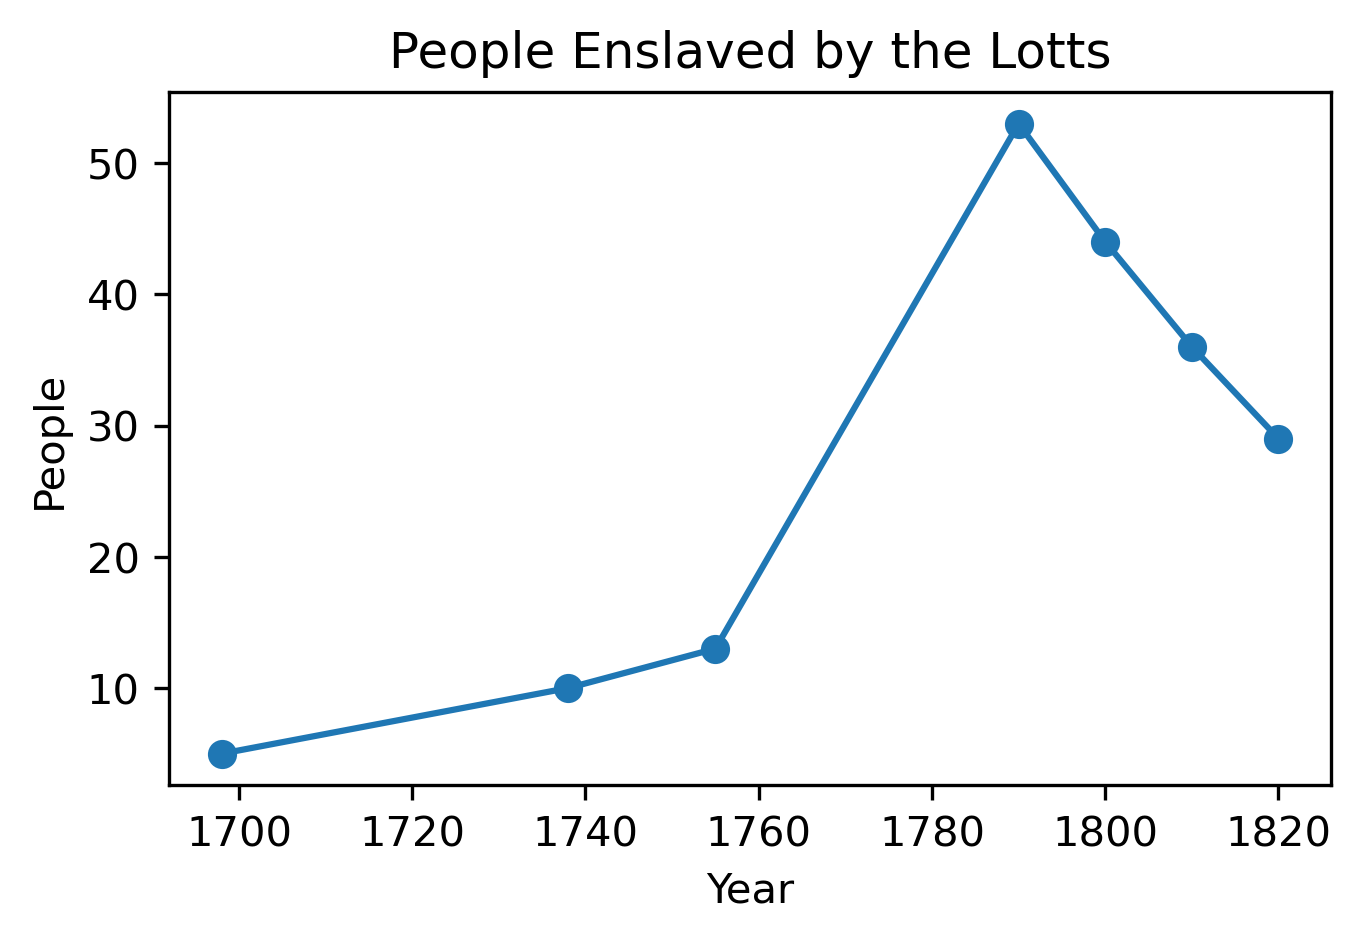

In [164]:
plt.figure(figsize=(5, 3), dpi=300)
plt.plot(lott_sum.index, lott_sum.values, marker="o")
plt.title("People Enslaved by the Lotts")
plt.xlabel("Year")
plt.ylabel("People")
# Saving the plot as a JPEG file
plt.savefig("lott_enslavedsum.jpg")
plt.show()

In [135]:
martense.nunique()

Column        21
State          1
Recnum        21
Type           1
RecYear        5
O_code         8
O_last         1
O_first       11
O_born         4
O_died         4
O_Gen          0
A_last         0
A_first        0
A_born         0
A_died         0
CountyBoro     1
Locality       1
Place          1
ShipName       0
Cemetery       1
Art_Site       0
Slaves         9
Sm             1
Sf             1
Smc            2
Sfc            1
E_code         9
E_last         0
E_first        8
E_born         0
E_died         0
Fam            0
E_sibling      0
E_parent       0
E_spouse       0
GenPop         8
Document       6
URL            0
Comment        0
Tag            1
Related        0
Cohort         1
CountRec       1
dtype: int64

In [137]:
martense_sum = martense.groupby("RecYear")[["Slaves"]].sum()

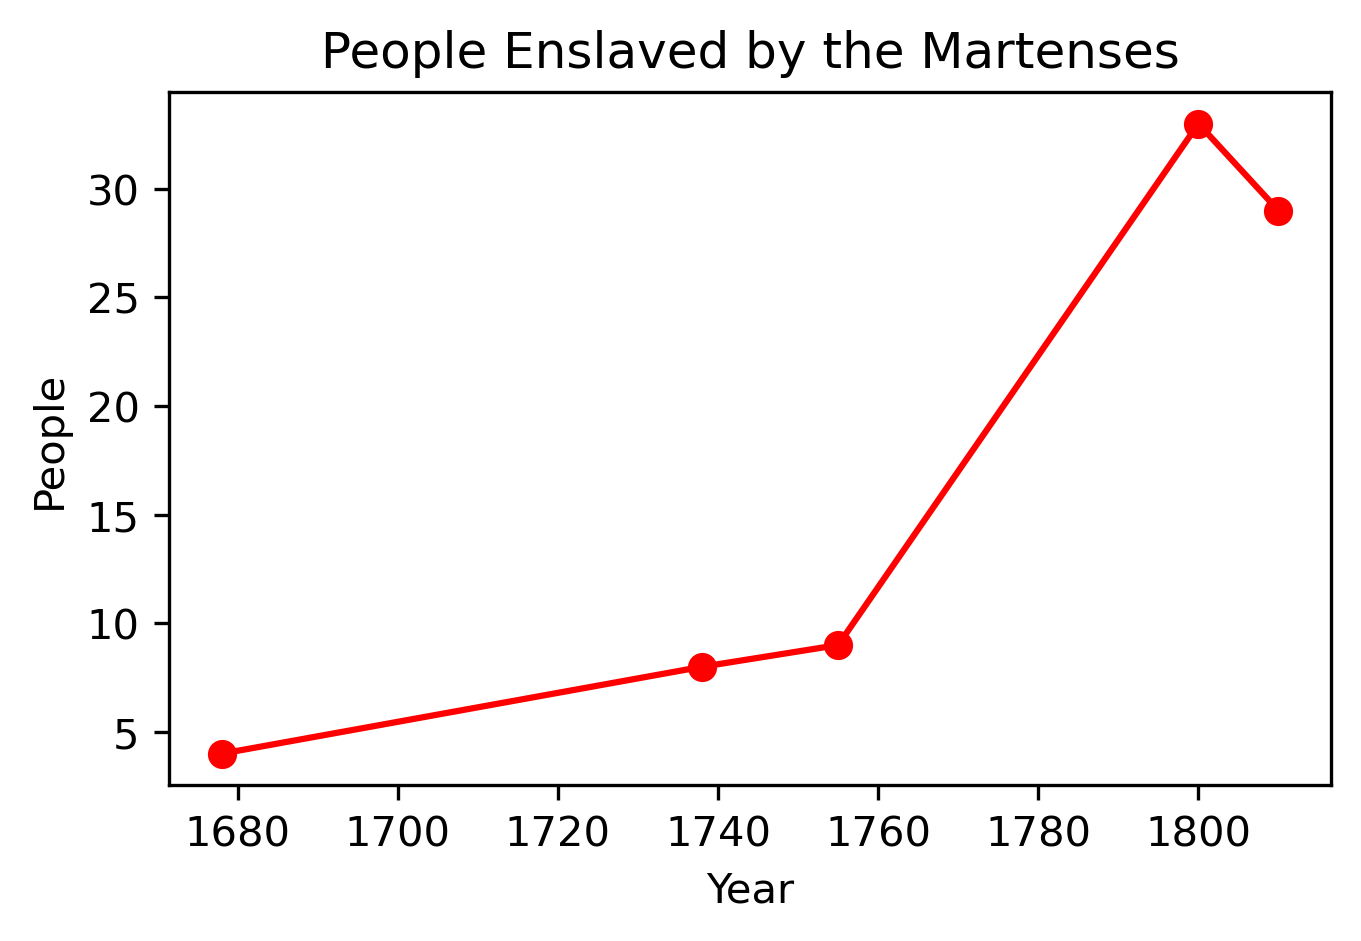

In [163]:
plt.figure(figsize=(5, 3), dpi=300)
plt.plot(martense_sum.index, martense_sum.values, marker="o", color='red')
plt.title("People Enslaved by the Martenses")
plt.xlabel("Year")
plt.ylabel("People")
# Saving the plot as a JPEG file
plt.savefig("martense_enslavedsum.jpg")
plt.show()

In [143]:
lefferts_sum = lefferts.groupby("RecYear")[["Slaves"]].sum()

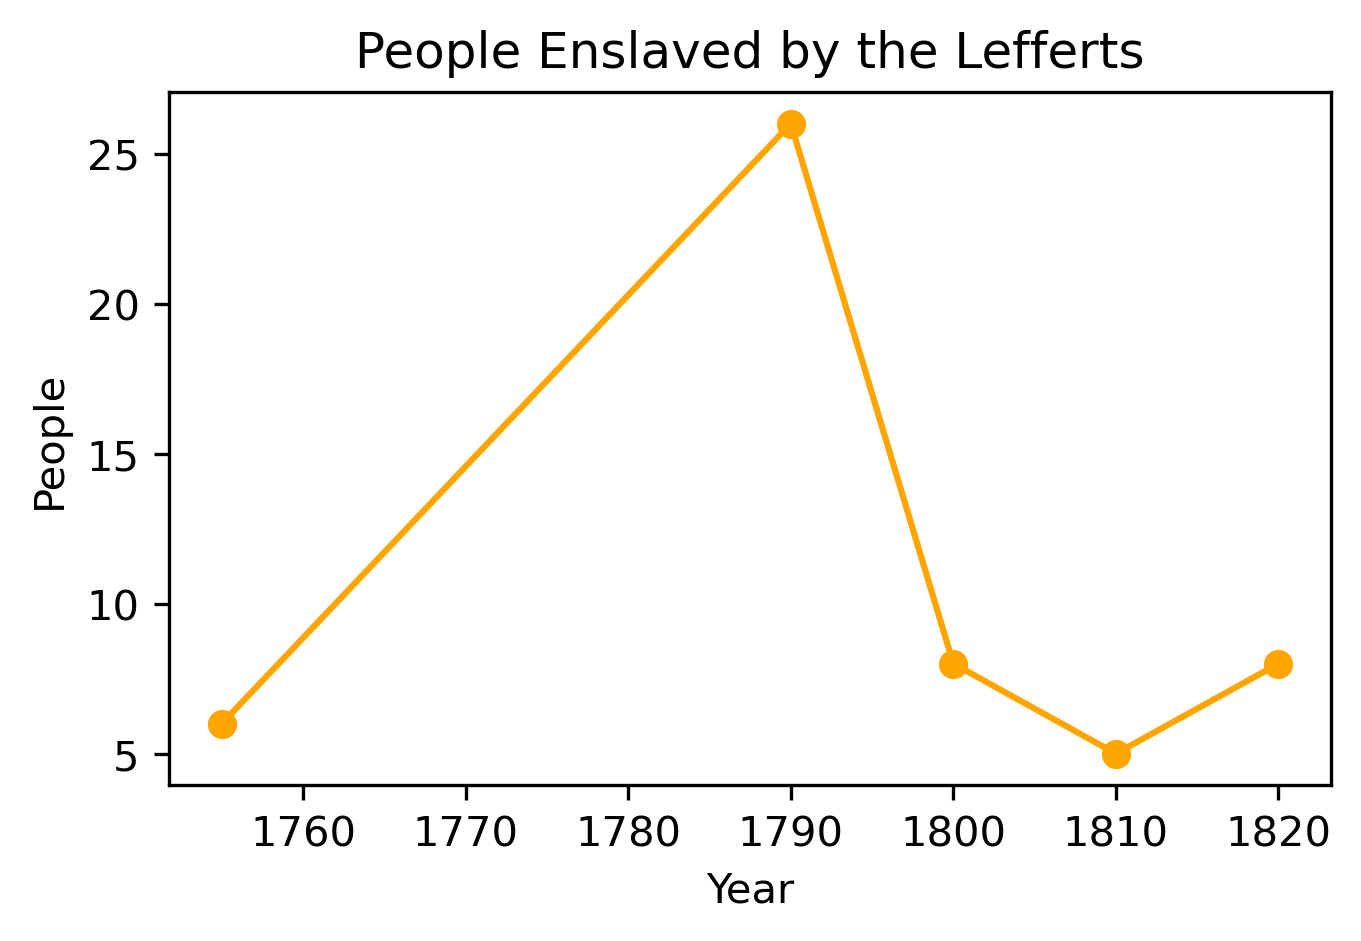

In [162]:
plt.figure(figsize=(5, 3), dpi=300)
plt.plot(lefferts_sum.index, lefferts_sum.values, marker="o", color='orange')
plt.title("People Enslaved by the Lefferts")
plt.xlabel("Year")
plt.ylabel("People")
# Saving the plot as a JPEG file
plt.savefig("lefferts_enslavedsum.jpg")
plt.show()

In [145]:
vanderveer_sum = vanderveer.groupby("RecYear")[["Slaves"]].sum()

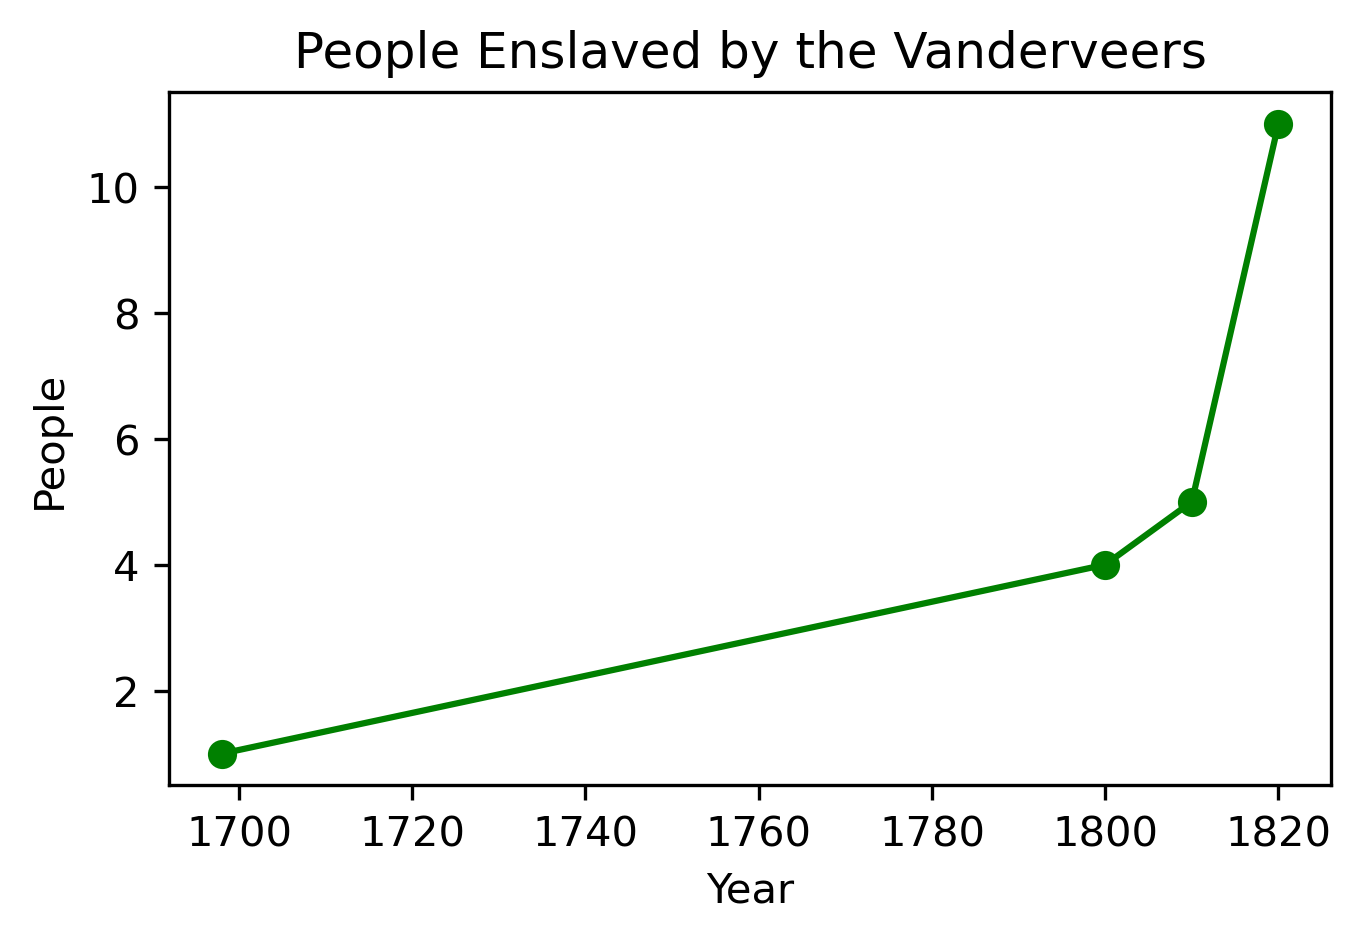

In [161]:
plt.figure(figsize=(5, 3), dpi=300)
plt.plot(vanderveer_sum.index, vanderveer_sum.values, marker="o", color='green')
plt.title("People Enslaved by the Vanderveers")
plt.xlabel("Year")
plt.ylabel("People")
# Saving the plot as a JPEG file
plt.savefig("vanderveer_enslavedsum.jpg")
plt.show()

In [147]:
remsen_sum = remsen.groupby("RecYear")[["Slaves"]].sum()

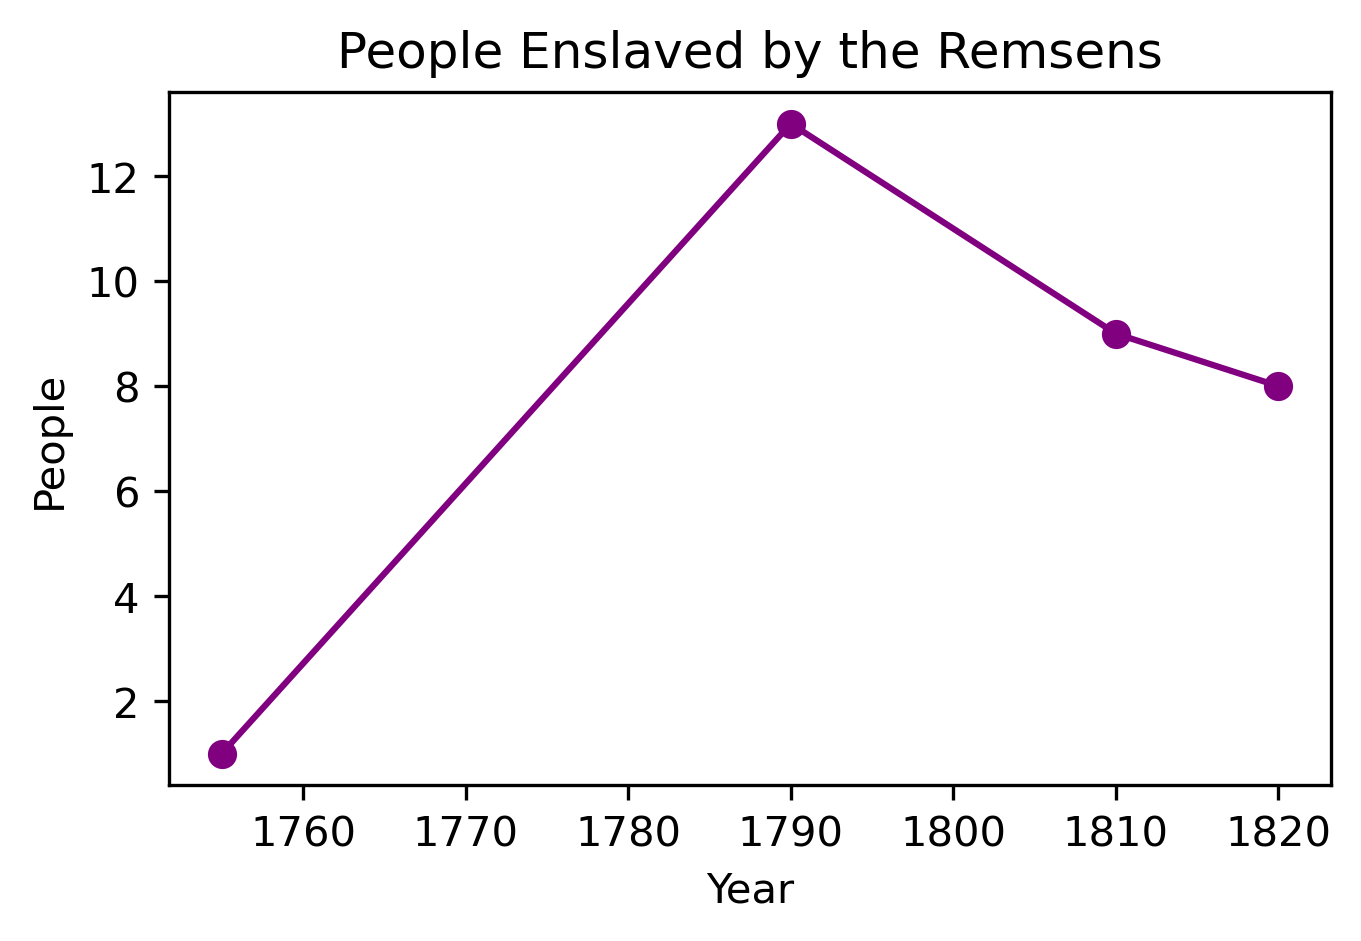

In [160]:
plt.figure(figsize=(5, 3), dpi=300)
plt.plot(remsen_sum.index, remsen_sum.values, marker="o", color='purple')
plt.title("People Enslaved by the Remsens")
plt.xlabel("Year")
plt.ylabel("People")
# Saving the plot as a JPEG file
plt.savefig("remsen_enslavedsum.jpg")
plt.show()

In [149]:
cortelyou_sum = cortelyou.groupby("RecYear")[["Slaves"]].sum()

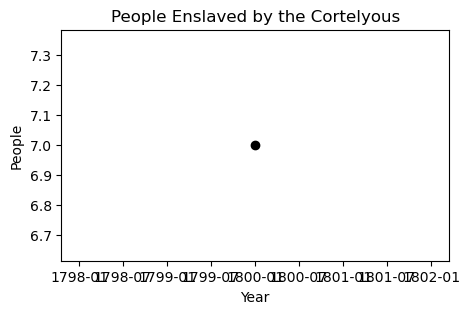

In [151]:
plt.figure(figsize=(5, 3))
plt.plot(cortelyou_sum.index, cortelyou_sum.values, marker="o", color='black')
plt.title("People Enslaved by the Cortelyous")
plt.xlabel("Year")
plt.ylabel("People")
# Saving the plot as a JPEG file
plt.savefig("cortelyou_enslavedsum.jpg")
plt.show()

In [153]:
cortelyou['Slaves']

91    7.0
Name: Slaves, dtype: float64

In [154]:
# need to edit this graph. present it differently

In [155]:
ditmas_sum = ditmas.groupby("RecYear")[["Slaves"]].sum()

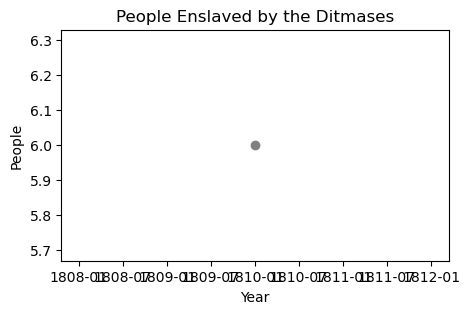

In [156]:
plt.figure(figsize=(5, 3))
plt.plot(ditmas_sum.index, ditmas_sum.values, marker="o", color='grey')
plt.title("People Enslaved by the Ditmases")
plt.xlabel("Year")
plt.ylabel("People")
# Saving the plot as a JPEG file
plt.savefig("ditmas_enslavedsum.jpg")
plt.show()

In [157]:
# create a multiline or bar chart of all families

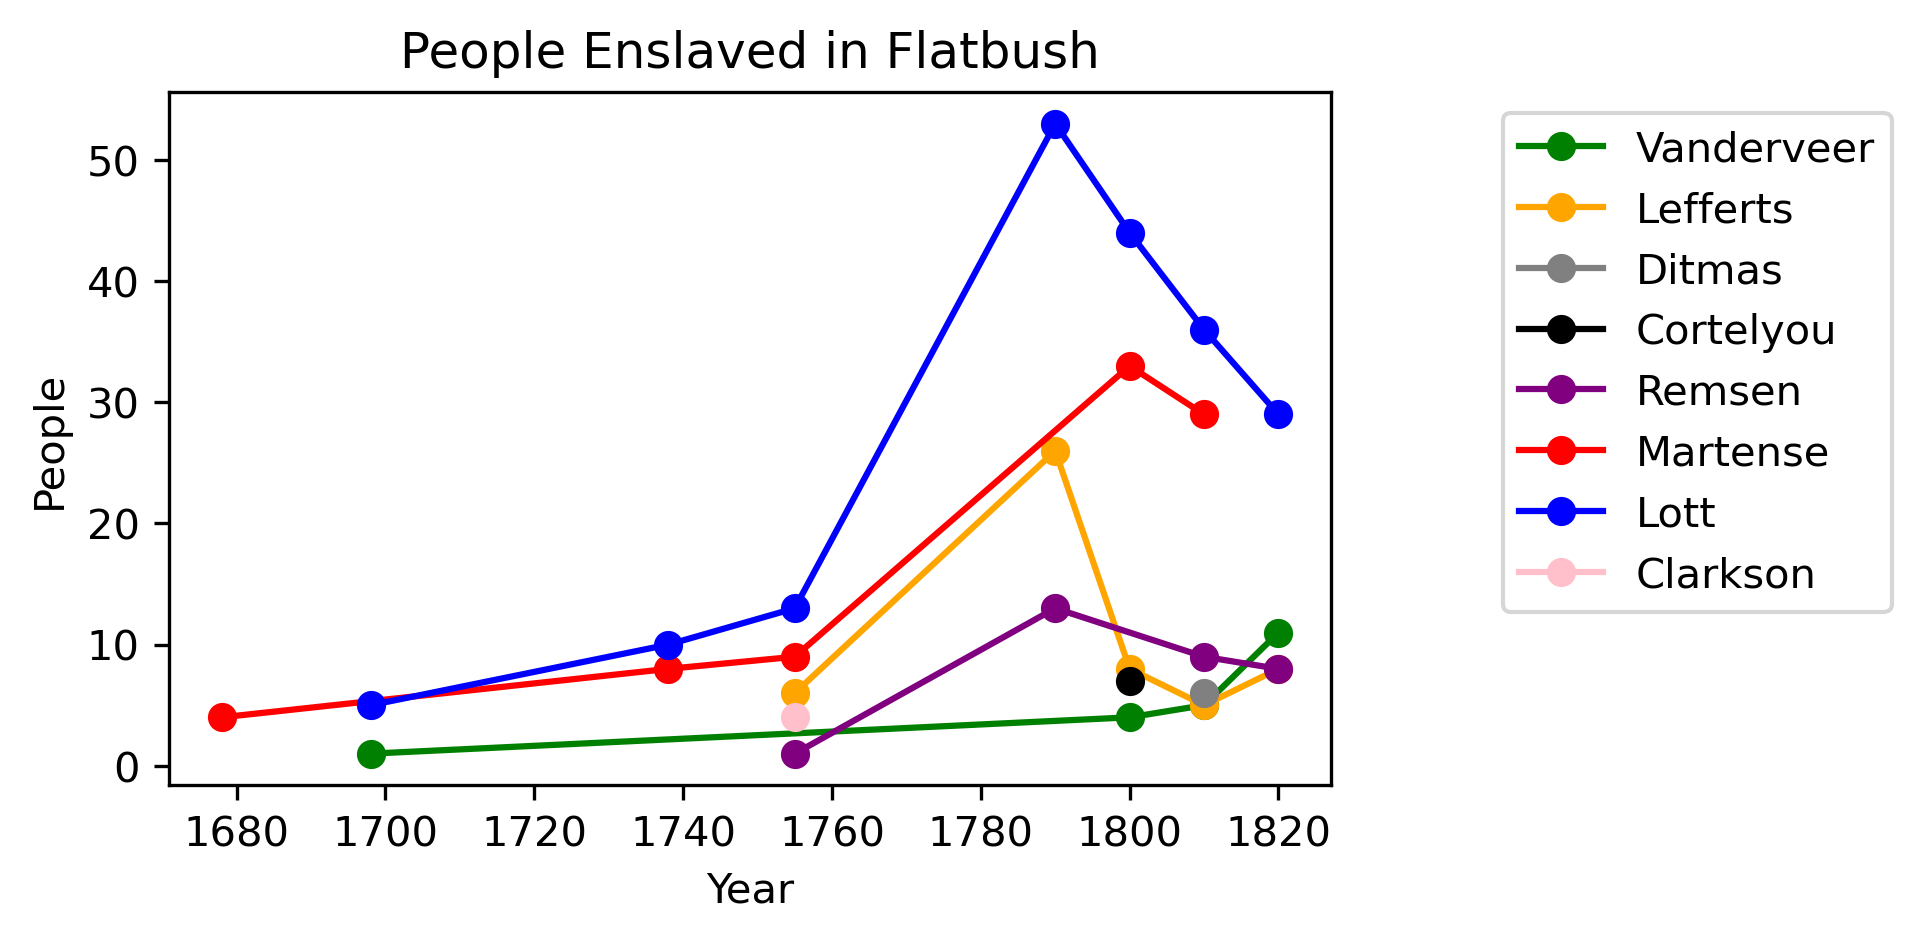

In [442]:
plt.figure(figsize=(5, 3), dpi=300, )
plt.plot(vanderveer_sum.index, vanderveer_sum.values, marker="o", color='green', label="Vanderveer")
plt.plot(lefferts_sum.index, lefferts_sum.values, marker="o", color='orange', label='Lefferts')
plt.plot(ditmas_sum.index, ditmas_sum.values, marker="o", color='grey', label="Ditmas")
plt.plot(cortelyou_sum.index, cortelyou_sum.values, marker="o", color='black', label="Cortelyou")
plt.plot(remsen_sum.index, remsen_sum.values, marker="o", color='purple', label="Remsen")
plt.plot(martense_sum.index, martense_sum.values, marker="o", color='red', label='Martense')
plt.plot(lott_sum.index, lott_sum.values, marker="o", color='blue', label='Lott')
plt.plot(clarkson_sum.index, clarkson_sum.values, marker="o", color='pink', label='Clarkson')
plt.title("People Enslaved in Flatbush")
plt.xlabel("Year")
plt.ylabel("People")
plt.legend(bbox_to_anchor=(1.50, 1.0), loc='upper right')
# Saving the plot as a JPEG file
plt.savefig("familiesline_enslavedsum.jpg", bbox_inches='tight')
plt.show()

In [201]:
enslavers['O_last'].value_counts()

O_last
Lott          43
Martense      21
Lefferts      13
Vanderveer    11
Remsen         6
Clarkson       5
Ditmas         1
Cortelyou      1
Name: count, dtype: int64

In [213]:
enslavers.groupby('O_last')
enslavers.groupby('O_last')['Slaves'].sum()
enslavers_sum = enslavers.groupby([pd.Grouper(key='RecYear'), 'O_last'])[['Slaves']].sum()
enslavers_sum

Slaves
RecYear    O_last            
1678-01-01 Martense       4.0
1698-01-01 Lott           5.0
           Vanderveer     1.0
1738-01-01 Lott          10.0
           Martense       8.0
1755-01-01 Clarkson       4.0
           Lefferts       6.0
           Lott          13.0
           Martense       9.0
           Remsen         1.0
1790-01-01 Lefferts      26.0
           Lott          53.0
           Remsen        13.0
1800-01-01 Cortelyou      7.0
           Lefferts       8.0
           Lott          44.0
           Martense      33.0
           Vanderveer     4.0
1802-01-01 Clarkson       0.0
1810-01-01 Ditmas         6.0
           Lefferts       5.0
           Lott          36.0
           Martense      29.0
           Remsen         9.0
           Vanderveer     5.0
1820-01-01 Lefferts       8.0
           Lott          29.0
           Remsen         8.0
           Vanderveer    11.0

In [430]:
import numpy as np

In [338]:
recyear = enslavers_sum.index.get_level_values("RecYear")
last = enslavers_sum.index.get_level_values("O_last")

In [431]:
# converted multiindex to regular dataframe so that it could be plotted as a bar chart. 

In [344]:
bar_enslavers_sum = enslavers_sum.reset_index()
bar_enslavers_sum


,RecYear,O_last,Slaves
0,1678-01-01,Martense,4.0
1,1698-01-01,Lott,5.0
2,1698-01-01,Vanderveer,1.0
3,1738-01-01,Lott,10.0
4,1738-01-01,Martense,8.0
5,1755-01-01,Clarkson,4.0
6,1755-01-01,Lefferts,6.0
7,1755-01-01,Lott,13.0
8,1755-01-01,Martense,9.0
9,1755-01-01,Remsen,1.0


In [435]:
bar_enslavers_sum = bar_enslavers_sum.rename(columns={
    "RecYear": "Year",
    "O_last": "Family",
    "Slaves": "Enslaved"
})

bar_enslavers_sum

,Year,Family,Enslaved
0,1678-01-01,Martense,4.0
1,1698-01-01,Lott,5.0
2,1698-01-01,Vanderveer,1.0
3,1738-01-01,Lott,10.0
4,1738-01-01,Martense,8.0
5,1755-01-01,Clarkson,4.0
6,1755-01-01,Lefferts,6.0
7,1755-01-01,Lott,13.0
8,1755-01-01,Martense,9.0
9,1755-01-01,Remsen,1.0


In [436]:
cleaned_enslavers_sum = bar_enslavers_sum.drop(index=18)

In [437]:
# dropped row with zero enslaved people
cleaned_enslavers_sum['Year']

0    1678-01-01
1    1698-01-01
2    1698-01-01
3    1738-01-01
4    1738-01-01
5    1755-01-01
6    1755-01-01
7    1755-01-01
8    1755-01-01
9    1755-01-01
10   1790-01-01
11   1790-01-01
12   1790-01-01
13   1800-01-01
14   1800-01-01
15   1800-01-01
16   1800-01-01
17   1800-01-01
19   1810-01-01
20   1810-01-01
21   1810-01-01
22   1810-01-01
23   1810-01-01
24   1810-01-01
25   1820-01-01
26   1820-01-01
27   1820-01-01
28   1820-01-01
Name: Year, dtype: datetime64[ns]

In [439]:

families_bar = alt.Chart(cleaned_enslavers_sum).mark_bar().encode(
    x=alt.X("Year:N", timeUnit='year', title='Year'),
    y="Enslaved:Q",
    xOffset="Family:N",
    color="Family:N",
    tooltip=['Family', 'Enslaved']
).properties(
    width=500,
    height=250
)
families_bar.save('families_bar.json')

In [497]:
families_bar

alt.Chart(...)

In [445]:
remsen_sum

,Slaves
RecYear,
1755-01-01,1.0
1790-01-01,13.0
1810-01-01,9.0
1820-01-01,8.0


In [462]:
len(remsen_sum.index.get_level_values("RecYear"))

4

In [485]:
reset_remsen = remsen_sum.reset_index()

In [527]:
# Create a line plot
remsen_linechart = alt.Chart(reset_remsen).mark_line(point=True).encode(
    x=alt.X("RecYear:T", timeUnit='year', title='Year', scale=alt.Scale(domain=(1745,1825))),
    y= alt.Y('Slaves', title='People', scale=alt.Scale(domain=(0,14))),
    tooltip=[alt.X("RecYear:T", timeUnit='year', title='Year'), alt.Y('Slaves', title='Enslaved People')],
    color=alt.value("#b279a2")
).properties(
    title='People Enslaved by the Remsen Family'
)

remsen_linechart.save('remsen_line.html')
remsen_linechart.save('remsen_line.json')

In [530]:
# create tables for Ditmas, Cortelyou, Clarkson enslaved people
# create dataframe for names of enslaved by family
# create geodataframes

In [531]:
ditmas_sum

,Slaves
RecYear,
1810-01-01,6.0


In [536]:
ditmas_sum.iloc[0].astype('int64')

Slaves    6
Name: 1810-01-01 00:00:00, dtype: int64

In [539]:
ditmas_sum = ditmas_sum.reset_index()

In [540]:
ditmas_sum

,RecYear,Slaves
0,1810-01-01,6.0


In [547]:
ditmas_sum.iloc[0,0].strftime('%Y')

'1810'

In [561]:
ditmas_sum['RecYear'].astype('str')

0    1810-01-01
Name: RecYear, dtype: object

In [652]:
ditmas_sum_table = ditmas_sum.copy()

In [653]:
ditmas_sum_table.loc['RecYear'] = '1810'

In [658]:
#ditmas_sum_table = ditmas_sum_table.drop(columns=0).copy()
#ditmas_sum_table = ditmas_sum_table.drop(index='RecYear').copy()
#ditmas_sum_table.dtypes
#ditmas_sum_table.info()
#ditmas_sum_table.loc[0,'RecYear'] = '1810'

In [659]:
ditmas_sum_table

,RecYear,Slaves
0,1810,6.0


In [660]:
ditmas_sum_table = ditmas_sum_table.rename(columns={
    'RecYear':'Year',
    'Slaves': 'Enslaved People'
}).copy()

In [661]:
ditmas_sum_table['Enslaved People'] = ditmas_sum_table['Enslaved People'].astype('int').copy()

In [662]:
ditmas_sum_table

,Year,Enslaved People
0,1810,6


In [663]:
ditmas_sum_table

#set style


ditmas_sum_table.style.set_table_styles({
    'Enslaved People': [{"selector": "td:hover", "props": [("background-color", "#e45756"), ("opacity", "80%")]}]
}).hide()

Year,Enslaved People
1810,6


In [664]:
ditmas_style_table = ditmas_sum_table.style.set_table_styles({
    'Enslaved People': [{"selector": "td:hover", "props": [("background-color", "#e45756"), ("opacity", "80%")]}]
}).hide()

In [666]:
ditmas_style_table.to_html('ditmas_table.html')

In [671]:
ditmas_sum_table.to_json('ditmas_sum_table.json')

In [679]:
ditmas_sum_table

,Year,Enslaved People
0,1810,6


In [676]:
# create Cortelyou table
# reset index, rename columns, change float to int, change year from time to str
# save as json, html
# apply styler
# save as html

In [715]:
cortelyou_sum_table = cortelyou_sum.reset_index().copy()

In [717]:
cortelyou_sum_table = cortelyou_sum_table.rename(columns={
    'RecYear':'Year',
    'Slaves': 'Enslaved People'
}).copy()

In [719]:
cortelyou_sum_table['Enslaved People'] = cortelyou_sum_table['Enslaved People'].astype('int').copy()

In [725]:
cortelyou_sum_table['Year'] = cortelyou_sum_table['Year'].astype('str').copy()

In [728]:
cortelyou_sum_table['Year'] = '1800'

In [733]:
cortelyou_sum_table.to_html('cortelyou_table_plain.html')

In [734]:
cortelyou_sum_table.to_json('cortelyou_table_plain.json')

In [736]:
# apply styler
cortelyou_sum_table.style.set_table_styles({
    'Enslaved People': [{"selector": "td:hover", "props": [("background-color", "#f58518"), ("opacity", "80%")]}]
}).hide()

Year,Enslaved People
1800,7


In [737]:
cortelyou_style_table = cortelyou_sum_table.style.set_table_styles({
    'Enslaved People': [{"selector": "td:hover", "props": [("background-color", "#f58518"), ("opacity", "80%")]}]
}).hide()

In [739]:
cortelyou_style_table.to_html('cortelyou_table.html')

In [740]:
# create Clarkson table
# reset index, rename columns, change float to int, change year from time to str
# save as json, html
# apply styler. color code = 4c78a8
# save as html

In [742]:
clarkson_sum_table = clarkson_sum.reset_index().copy()

In [744]:
clarkson_sum_table = clarkson_sum_table.rename(columns={
    'RecYear':'Year',
    'Slaves': 'Enslaved People'
}).copy()

In [746]:
clarkson_sum_table['Enslaved People'] = clarkson_sum_table['Enslaved People'].astype('int').copy()

In [751]:
clarkson_sum_table['Year'] = clarkson_sum_table['Year'].astype('str').copy()
clarkson_sum_table['Year']

0    1755-01-01
Name: Year, dtype: object

In [752]:
clarkson_sum_table['Year'] = '1755'

In [754]:
clarkson_sum_table.to_html('clarkson_table_plain.html')

In [755]:
clarkson_sum_table.to_json('clarkson_table_plain.json')

In [756]:
# apply styler
clarkson_sum_table.style.set_table_styles({
    'Enslaved People': [{"selector": "td:hover", "props": [("background-color", "#4c78a8"), ("opacity", "80%")]}]
}).hide()

Year,Enslaved People
1755,4


In [757]:
clarkson_style_table = clarkson_sum_table.style.set_table_styles({
    'Enslaved People': [{"selector": "td:hover", "props": [("background-color", "#4c78a8"), ("opacity", "80%")]}]
}).hide()

In [759]:
clarkson_style_table.to_html('clarkson_table.html')

In [760]:
# create dataframe with enslaved names by family

In [775]:
rawdata['E_code'].value_counts()
rawdata['E_code'].notnull()

# use previous filter: is_in_flatbush = rawdata['Place'] == 'Flatbush'

raw_names_fb = rawdata[rawdata['E_code'].notnull() & is_in_flatbush].copy()

In [801]:
# remove extra columns
#raw_names_fb.loc[1467]
#raw_names_fb = raw_names_fb.drop(index=1467)
raw_names_fb.info()


<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 28 to 3349
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   State       394 non-null    object 
 1   Recnum      394 non-null    int64  
 2   Type        394 non-null    object 
 3   RecYear     394 non-null    float64
 4   O_code      394 non-null    object 
 5   O_last      394 non-null    object 
 6   O_first     390 non-null    object 
 7   O_born      100 non-null    float64
 8   O_died      105 non-null    float64
 9   O_Gen       40 non-null     object 
 10  A_last      0 non-null      float64
 11  A_first     0 non-null      float64
 12  A_born      0 non-null      float64
 13  A_died      0 non-null      float64
 14  CountyBoro  394 non-null    object 
 15  Locality    394 non-null    object 
 16  Place       394 non-null    object 
 17  ShipName    0 non-null      float64
 18  Cemetery    28 non-null     object 
 19  Art_Site    0 non-null      obje

In [809]:
#filter by 8 family names: Lott, Martense, Lefferts, Vanderveer, Remsen, Cortelyou, Clarkson, Ditmas
names_in_lott = raw_names_fb['O_last'] == 'Lott'
names_in_martense = raw_names_fb['O_last'] == 'Martense'
names_in_lefferts = raw_names_fb['O_last'] == 'Lefferts'
names_in_vanderveer = raw_names_fb['O_last'] == 'Vanderveer'
names_in_remsen = raw_names_fb['O_last'] == 'Remsen'
names_in_cortelyou = raw_names_fb['O_last'] == 'Cortelyou'
names_in_clarkson = raw_names_fb['O_last'] == 'Clarkson'
names_in_ditmas = raw_names_fb['O_last'] == 'Ditmas'


In [810]:
raw_names_fb[names_in_lott | names_in_clarkson | names_in_cortelyou | names_in_ditmas | names_in_lefferts | names_in_martense | names_in_remsen | names_in_vanderveer]



,State,Recnum,Type,RecYear,O_code,O_last,O_first,O_born,O_died,O_Gen,...,E_parent,E_spouse,GenPop,Document,URL,Comment,Tag,Related,Cohort,CountRec
29,NY,198091,Enslaved,1810.0,NY_LeffPheb_01,Lefferts,Phebe,NaN,NaN,NaN,...,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG FES,NaN,2025Flatbush,1
133,NY,167920,Enslaver,1755.0,NY_LeffPete_01,Lefferts,Pieter,1680.0,1774.0,https://www.wikitree.com/wiki/Lefferts-41,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
144,NY,198102,Enslaved,1815.0,NY_LottJoha_02,Lott,Johannes E,NaN,1813.0,NaN,...,NY__Isabel_21266,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,NaN,2025Flatbush,1
151,NY,169034,Enslaver,1755.0,NY_MartAdri_01,Martense,Adrian,1707.0,1780.0,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
152,NY,169969,Enslaver,1755.0,NY_MartLeff_01,Martense,Leffert,NaN,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3290,NY,198092,Enslaved,1812.0,NY_LeffPheb_01,Lefferts,Phebe,NaN,NaN,NaN,...,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,NaN,2025Flatbush,1
3298,NY,170885,Enslaver,1755.0,NY_LottJaco_01,Lott,Jacobus,NaN,NaN,NaN,...,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,NaN,Addition_20240126,1
3299,NY,198111,Enslaved,1812.0,NY_LottJohn_02,Lott,John,NaN,NaN,NaN,...,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,NaN,2025Flatbush,1
3307,NY,198126,Enslaved,1811.0,NY_MartAdri_02,Martense,Adrian Jr,1742.0,1817.0,NaN,...,NY__Mary_21272,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,NaN,2025Flatbush,1


In [811]:
names_in_fb = raw_names_fb[names_in_lott | names_in_clarkson | names_in_cortelyou | names_in_ditmas | names_in_lefferts | names_in_martense | names_in_remsen | names_in_vanderveer].copy()

In [814]:
# delete extraneous columns

names_in_fb = names_in_fb.drop(columns=['State', 'CountyBoro', 'Cemetery', 'Art_Site', 'A_last', 'A_first', 'A_born', 'A_died', 'GenPop', 'Related'])

In [824]:
names_in_fb[names_in_fb['Comment'].notnull()]['Comment']
names_in_fb.loc[985, 'Comment']
names_in_fb.loc[2206, 'Comment']

'Dina was enslaved by John Cortelyou and then by Ann McLeod.'

In [826]:
names_clarkson = names_in_fb['O_last'] == 'Clarkson'

In [945]:
names_in_fb[names_in_remsen]['E_code']

/var/folders/ty/t5g04mnj6x93zg7hdrctg18c0000gn/T/ipykernel_2996/1288089296.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  names_in_fb[names_in_remsen]['E_code']


Series([], Name: E_code, dtype: object)

In [832]:
# create list of names in new dataframe
# ex: Lott | geometry | Lott st | names (first and last if possible) [dataframe for tooltip]
# use vega charts in json for pop-up

**Sorting and cleaning names_in_fb dataframe to prepare for geodataframes**

In [838]:
names_in_fb.sort_values(by=['O_last'])
#change index to O_last
names_in_fb.set_index('O_last')

,Recnum,Type,RecYear,O_code,O_first,O_born,O_died,O_Gen,Locality,Place,...,Fam,E_sibling,E_parent,E_spouse,Document,URL,Comment,Tag,Cohort,CountRec
O_last,,,,,,,,,,,,,,,,,,,,,
Lefferts,198091,Enslaved,1810.0,NY_LeffPheb_01,Phebe,NaN,NaN,NaN,Brooklyn,Flatbush,...,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG FES,2025Flatbush,1
Lefferts,167920,Enslaver,1755.0,NY_LeffPete_01,Pieter,1680.0,1774.0,https://www.wikitree.com/wiki/Lefferts-41,Brooklyn,Flatbush,...,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,Addition_20240126,1
Lott,198102,Enslaved,1815.0,NY_LottJoha_02,Johannes E,NaN,1813.0,NaN,Brooklyn,Flatbush,...,NY__Isabel_21266,NaN,NY__Isabel_21266,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,2025Flatbush,1
Martense,169034,Enslaver,1755.0,NY_MartAdri_01,Adrian,1707.0,1780.0,NaN,Brooklyn,Flatbush,...,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,Addition_20240126,1
Martense,169969,Enslaver,1755.0,NY_MartLeff_01,Leffert,NaN,NaN,NaN,Brooklyn,Flatbush,...,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,Addition_20240126,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Lefferts,198092,Enslaved,1812.0,NY_LeffPheb_01,Phebe,NaN,NaN,NaN,Brooklyn,Flatbush,...,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,2025Flatbush,1
Lott,170885,Enslaver,1755.0,NY_LottJaco_01,Jacobus,NaN,NaN,NaN,Brooklyn,Flatbush,...,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,Addition_20240126,1
Lott,198111,Enslaved,1812.0,NY_LottJohn_02,John,NaN,NaN,NaN,Brooklyn,Flatbush,...,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,2025Flatbush,1


In [844]:
names_cleaning = names_in_fb.set_index('O_last').sort_values(by='O_last')

In [1096]:
# pull out columns in a list
filtered_columns = ['RecYear', 'O_code', 'O_first', 'ShipName', 'Slaves', 'Sm', 'Sf', 'Smc', 'Sfc', 'E_code', 
'E_last', 'E_first', 'E_born', 'E_died', 'Fam', 'E_sibling', 'E_parent', 'E_spouse', 'Document',
'URL', 'Comment']

names_cleaning.info()
names_cleaning.nunique()
names_cleaning[names_cleaning['E_code'].duplicated(keep=False)]
# there is a duplicate in Martense to be aware of
names_in_fb[names_in_fb['E_code'].duplicated(keep=False)].loc[[1199, 3308],['E_code', 'E_first', 'URL']]
names_in_fb.drop_duplicates('E_code')
names_in_fbdd = names_in_fb.drop_duplicates('E_code')
names_in_fbdd

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, Clarkson to Vanderveer
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recnum     101 non-null    int64  
 1   Type       101 non-null    object 
 2   RecYear    101 non-null    float64
 3   O_code     101 non-null    object 
 4   O_first    97 non-null     object 
 5   O_born     37 non-null     float64
 6   O_died     40 non-null     float64
 7   O_Gen      3 non-null      object 
 8   Locality   101 non-null    object 
 9   Place      101 non-null    object 
 10  ShipName   0 non-null      float64
 11  Slaves     101 non-null    float64
 12  Sm         17 non-null     float64
 13  Sf         19 non-null     float64
 14  Smc        36 non-null     float64
 15  Sfc        28 non-null     float64
 16  E_code     101 non-null    object 
 17  E_last     1 non-null      object 
 18  E_first    101 non-null    object 
 19  E_born     65 non-null     float64
 20  E

,Recnum,Type,RecYear,O_code,O_last,O_first,O_born,O_died,O_Gen,Locality,...,Fam,E_sibling,E_parent,E_spouse,Document,URL,Comment,Tag,Cohort,CountRec
29,198091,Enslaved,1810.0,NY_LeffPheb_01,Lefferts,Phebe,NaN,NaN,NaN,Brooklyn,...,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG FES,2025Flatbush,1
133,167920,Enslaver,1755.0,NY_LeffPete_01,Lefferts,Pieter,1680.0,1774.0,https://www.wikitree.com/wiki/Lefferts-41,Brooklyn,...,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,Addition_20240126,1
144,198102,Enslaved,1815.0,NY_LottJoha_02,Lott,Johannes E,NaN,1813.0,NaN,Brooklyn,...,NY__Isabel_21266,NaN,NY__Isabel_21266,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,2025Flatbush,1
151,169034,Enslaver,1755.0,NY_MartAdri_01,Martense,Adrian,1707.0,1780.0,NaN,Brooklyn,...,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,Addition_20240126,1
152,169969,Enslaver,1755.0,NY_MartLeff_01,Martense,Leffert,NaN,NaN,NaN,Brooklyn,...,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,Addition_20240126,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3190,198146,Enslaved,1813.0,NY_MartSeyt_01,Martense,Siteye,NaN,NaN,NaN,Brooklyn,...,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,2025Flatbush,1
3290,198092,Enslaved,1812.0,NY_LeffPheb_01,Lefferts,Phebe,NaN,NaN,NaN,Brooklyn,...,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,2025Flatbush,1
3298,170885,Enslaver,1755.0,NY_LottJaco_01,Lott,Jacobus,NaN,NaN,NaN,Brooklyn,...,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",NaN,NaN,NaN,Addition_20240126,1
3299,198111,Enslaved,1812.0,NY_LottJohn_02,Lott,John,NaN,NaN,NaN,Brooklyn,...,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN,BIRTHREG,2025Flatbush,1


In [861]:
names_cleaning.loc['Clarkson', filtered_columns]

,RecYear,O_code,O_first,ShipName,Slaves,Sm,Sf,Smc,Sfc,E_code,...,E_first,E_born,E_died,Fam,E_sibling,E_parent,E_spouse,Document,URL,Comment
O_last,,,,,,,,,,,,,,,,,,,,,
Clarkson,1755.0,NY_Clar_01,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NY__Saar_15643,...,Saar,NaN,NaN,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN
Clarkson,1755.0,NY_Clar_01,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NY__Ben_10351,...,Ben,NaN,NaN,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN
Clarkson,1755.0,NY_Clar_01,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NY__Jafta_13085,...,Jafta,NaN,NaN,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN
Clarkson,1755.0,NY_Clar_01,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NY__Henck_12596,...,Henck,NaN,NaN,NaN,NaN,NaN,NaN,"Conway, Rosanne: Lists of Inhabitants of Colon...",Widow,NaN


In [1107]:
# create function for apply method to create series of names
family_dict = {}
clarkson_list = []
cortelyou_list = []
ditmas_list = []
lefferts_list = []
lott_list = []
martense_list = []
remsen_list = []
vanderveer_list = []

In [1108]:


def list_of_names(row):
    
    family_name = row.loc['O_last']
    first_name = row.loc['E_first']

    if family_name == 'Clarkson':
        clarkson_list.append(first_name)
        family_dict.update({family_name: clarkson_list})
    if family_name == 'Cortelyou':
        cortelyou_list.append(first_name)
        family_dict.update({family_name: cortelyou_list})
    if family_name == 'Ditmas':
        ditmas_list.append(first_name)
        family_dict.update({family_name: ditmas_list})
    if family_name == 'Lefferts':
        lefferts_list.append(first_name)
        family_dict.update({family_name: lefferts_list})
    if family_name == 'Lott':
        lott_list.append(first_name)
        family_dict.update({family_name: lott_list})
    if family_name == 'Martense':
        martense_list.append(first_name)
        family_dict.update({family_name: martense_list})
    if family_name == 'Remsen':
        remsen_list.append(first_name)
        family_dict.update({family_name: remsen_list})
    if family_name == 'Vanderveer':
        vanderveer_list.append(first_name)
        family_dict.update({family_name: vanderveer_list})
    

In [999]:
names_test = names_cleaning.loc['Cortelyou', filtered_columns]
names_test

,RecYear,O_code,O_first,ShipName,Slaves,Sm,Sf,Smc,Sfc,E_code,...,E_first,E_born,E_died,Fam,E_sibling,E_parent,E_spouse,Document,URL,Comment
O_last,,,,,,,,,,,,,,,,,,,,,
Cortelyou,1880.0,NY_CortelyJohn_01,John,NaN,1.0,NaN,NaN,1.0,NaN,NY__Sick_21066,...,Sick,1803.0,NaN,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN
Cortelyou,1813.0,NY_CortelyJohn_01,John,NaN,1.0,NaN,NaN,NaN,1.0,NY__Dina_21192,...,Dina,1813.0,NaN,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",Dina was enslaved by John Cortelyou and then b...
Cortelyou,1806.0,NY_CortelyJohn_01,John,NaN,1.0,NaN,NaN,1.0,NaN,NY__Tom_21112,...,Tom,1806.0,NaN,NaN,NaN,NaN,NaN,MSS0004_2_04_01_092_001 FlatbushSlaveryRecords...,"<A href=""https://nycrecords.access.preservica....",NaN


In [1109]:
names_in_fbdd.apply(list_of_names, axis='columns')


29      None
133     None
144     None
151     None
152     None
        ... 
3190    None
3290    None
3298    None
3299    None
3307    None
Length: 100, dtype: object

In [1110]:
clarkson_list
cortelyou_list
ditmas_list
lefferts_list
lott_list
martense_list
#remsen_list : no names under Remsen family recorded
vanderveer_list

['Deyawn', 'Francis', 'Joe', 'Sawr']

In [1111]:
family_dict

{'Lefferts': ['Jack',
  'Isabel',
  'Samuel',
  'Isabella',
  'Cato',
  'Mercy',
  'Isabella',
  'Dyne',
  'Tom',
  'Prins',
  'Herry',
  'Cato',
  'Rachel',
  'Ben',
  'Grace',
  'Mary',
  'Nan'],
 'Lott': ['Francis',
  'Sarah',
  'Bet',
  'Tom',
  'Sarah',
  'Bett',
  'Cuff',
  'Will',
  'Caty',
  'Batt',
  'Jan',
  'Albert',
  'Harry',
  'William',
  'Patience',
  'Syne',
  'Jafta',
  'Tom',
  'Jack',
  'Wyne',
  'Dine',
  'Sare',
  'Eva',
  'Judi',
  'Teen',
  'Gabriel',
  'Nat',
  'Isabel',
  'Sam',
  'Sam',
  'Sarah'],
 'Martense': ['Lans',
  'Pagg',
  'Margaret',
  'Mary',
  'Isabella',
  'Sare',
  'Bet',
  'Bet',
  'Lane',
  'Bill',
  'Thomas',
  'Yafth',
  'Jude',
  'Herry',
  'Dick',
  'Nienus',
  'Harry',
  'Susan',
  'Hester',
  'Dine',
  'Sam',
  'Will',
  'Harry',
  'Frank',
  'Frances',
  'Molly',
  'Lid',
  'Mink',
  'Titus',
  'Jerrey',
  'Jerry',
  'Bet',
  'Emme',
  'Frank',
  'Susan',
  'Isabel',
  'Sam',
  'Bill',
  'Dine'],
 'Clarkson': ['Henck', 'Saar', 'Ben', 'J

In [1112]:
family_series = pd.Series(family_dict)

In [1113]:
family_series

Lefferts      [Jack, Isabel, Samuel, Isabella, Cato, Mercy, ...
Lott          [Francis, Sarah, Bet, Tom, Sarah, Bett, Cuff, ...
Martense      [Lans, Pagg, Margaret, Mary, Isabella, Sare, B...
Clarkson                              [Henck, Saar, Ben, Jafta]
Cortelyou                                     [Sick, Dina, Tom]
Ditmas                                           [Jacob, Harry]
Vanderveer                         [Deyawn, Francis, Joe, Sawr]
dtype: object

In [1114]:
family_df = pd.DataFrame(family_series)

In [1115]:
family_df

,0
Lefferts,"[Jack, Isabel, Samuel, Isabella, Cato, Mercy, ..."
Lott,"[Francis, Sarah, Bet, Tom, Sarah, Bett, Cuff, ..."
Martense,"[Lans, Pagg, Margaret, Mary, Isabella, Sare, B..."
Clarkson,"[Henck, Saar, Ben, Jafta]"
Cortelyou,"[Sick, Dina, Tom]"
Ditmas,"[Jacob, Harry]"
Vanderveer,"[Deyawn, Francis, Joe, Sawr]"


In [1116]:
family_df = family_df.rename(columns={0:'Enslaved Names'})

In [1117]:
family_df

,Enslaved Names
Lefferts,"[Jack, Isabel, Samuel, Isabella, Cato, Mercy, ..."
Lott,"[Francis, Sarah, Bet, Tom, Sarah, Bett, Cuff, ..."
Martense,"[Lans, Pagg, Margaret, Mary, Isabella, Sare, B..."
Clarkson,"[Henck, Saar, Ben, Jafta]"
Cortelyou,"[Sick, Dina, Tom]"
Ditmas,"[Jacob, Harry]"
Vanderveer,"[Deyawn, Francis, Joe, Sawr]"


In [1118]:
family_df.to_json('family_df.json')
  

In [1119]:
#Create geo dataframe

In [1120]:
import pygris as pyg
from pygris.geocode import geocode as pygeocode

In [1121]:
# create dataframe with street names

In [1122]:
pyg.roads(county = "Kings", state = "NY")

Using the default year of 2024
Using FIPS code '36' for input 'NY'
Using FIPS code '047' for input 'Kings'


,LINEARID,FULLNAME,RTTYP,MTFCC,geometry
0,110422531494,E 28th St Exd,M,S1400,"LINESTRING (-73.94106 40.58566, -73.94102 40.5..."
1,110422542973,Pierrepont St Exd,M,S1400,"LINESTRING (-73.99782 40.69651, -73.99716 40.6..."
2,110422536875,Little St Exd,M,S1400,"LINESTRING (-73.97917 40.7053, -73.97917 40.70..."
3,110422538006,Otsego St Exd,M,S1400,"LINESTRING (-74.01187 40.67047, -74.01189 40.6..."
4,110422533757,Coyle St Exd,M,S1400,"LINESTRING (-73.93445 40.58665, -73.93441 40.5..."
...,...,...,...,...,...
3491,11012812715972,None,None,S1710,"LINESTRING (-73.96068 40.7029, -73.96136 40.70..."
3492,11012812724997,None,None,S1780,"LINESTRING (-73.97492 40.57617, -73.97477 40.5..."
3493,11017129197264,Atlantic Ave,M,S1400,"LINESTRING (-74.00015 40.69193, -74.00061 40.6..."
3494,110422541699,Parkside Ct,M,S1400,"LINESTRING (-73.96091 40.65616, -73.9607 40.65..."


In [1123]:
roads_gdf = pyg.roads(county = "Kings", state = "NY")

Using the default year of 2024
Using FIPS code '36' for input 'NY'
Using FIPS code '047' for input 'Kings'


In [1136]:
lott_geo = roads_gdf['FULLNAME'].str.contains('Lott')


In [1144]:
named_roads_gdf = roads_gdf[roads_gdf['FULLNAME'].notnull()]

In [1146]:
lott_geo = named_roads_gdf['FULLNAME'].str.contains('Lott')

In [1147]:
named_roads_gdf[lott_geo]

,LINEARID,FULLNAME,RTTYP,MTFCC,geometry
1106,110422532813,Lott St,M,S1400,"LINESTRING (-73.95421 40.64794, -73.95412 40.6..."
1765,110422534414,Lotts Ln,M,S1400,"LINESTRING (-73.93607 40.61844, -73.93699 40.6..."
1850,110422532812,Lott St,M,S1400,"LINESTRING (-73.95417 40.64959, -73.95409 40.6..."
2886,110422532802,Lott Ave,M,S1400,"LINESTRING (-73.91403 40.657, -73.91334 40.657..."
3339,110422532808,Lott Pl,M,S1400,"LINESTRING (-73.93613 40.62192, -73.93496 40.6..."


In [1148]:
lott_gdf = named_roads_gdf[lott_geo]

In [1149]:
lott_gdf.explore()

In [1152]:
lott_gdf.drop([1765,2886,3339])

,LINEARID,FULLNAME,RTTYP,MTFCC,geometry
1106,110422532813,Lott St,M,S1400,"LINESTRING (-73.95421 40.64794, -73.95412 40.6..."
1850,110422532812,Lott St,M,S1400,"LINESTRING (-73.95417 40.64959, -73.95409 40.6..."


In [1153]:
lott_gdf = lott_gdf.drop([1765,2886,3339])

In [1156]:
is_on_lefferts = named_roads_gdf['FULLNAME'].str.contains('Lefferts')
is_on_cortelyou = named_roads_gdf['FULLNAME'].str.contains('Cortelyou')
is_on_martense = named_roads_gdf['FULLNAME'].str.contains('Martense')
is_on_clarkson = named_roads_gdf['FULLNAME'].str.contains('Clarkson')
is_on_remsen = named_roads_gdf['FULLNAME'].str.contains('Remsen')
is_on_vanderveer = named_roads_gdf['FULLNAME'].str.contains('Vanderveer')
is_on_ditmas = named_roads_gdf['FULLNAME'].str.contains('Ditmas')

In [1158]:
#filter for all streets
named_roads_gdf[is_on_clarkson | is_on_cortelyou | is_on_martense | is_on_lefferts | is_on_remsen | is_on_ditmas | is_on_vanderveer]



,LINEARID,FULLNAME,RTTYP,MTFCC,geometry
857,110422538084,Remsen Ave,M,S1400,"LINESTRING (-73.93158 40.66323, -73.93108 40.6..."
1133,110422541457,Lefferts Pl,M,S1400,"LINESTRING (-73.96347 40.68187, -73.96142 40.6..."
1354,110422541060,Clarkson Ave,M,S1400,"LINESTRING (-73.9597 40.65484, -73.9563 40.655..."
1369,110422541061,Clarkson Ave,M,S1400,"LINESTRING (-73.92541 40.65768, -73.92464 40.6..."
1375,110422535821,Ditmas Ave,M,S1400,"LINESTRING (-73.92262 40.64273, -73.92174 40.6..."
1731,110422535822,Ditmas Ave,M,S1400,"LINESTRING (-73.97911 40.63544, -73.97802 40.6..."
1851,110422543072,Vanderveer Pl,M,S1400,"LINESTRING (-73.95707 40.64196, -73.95541 40.6..."
2059,110422541452,Lefferts Ave,M,S1400,"LINESTRING (-73.96143 40.66169, -73.96077 40.6..."
2183,110422535820,Ditmas Ave,M,S1400,"LINESTRING (-73.96763 40.63524, -73.96712 40.6..."
2300,110422542259,Cortelyou Rd,M,S1400,"LINESTRING (-73.97955 40.63782, -73.97912 40.6..."


In [1159]:
family_roads_gdf = named_roads_gdf[is_on_clarkson | is_on_cortelyou | is_on_martense | is_on_lefferts | is_on_remsen | is_on_ditmas | is_on_vanderveer]

In [1160]:
family_roads_gdf.explore()

In [1161]:
family_roads_gdf.drop([1133, 3235, 2404])

,LINEARID,FULLNAME,RTTYP,MTFCC,geometry
857,110422538084,Remsen Ave,M,S1400,"LINESTRING (-73.93158 40.66323, -73.93108 40.6..."
1354,110422541060,Clarkson Ave,M,S1400,"LINESTRING (-73.9597 40.65484, -73.9563 40.655..."
1369,110422541061,Clarkson Ave,M,S1400,"LINESTRING (-73.92541 40.65768, -73.92464 40.6..."
1375,110422535821,Ditmas Ave,M,S1400,"LINESTRING (-73.92262 40.64273, -73.92174 40.6..."
1731,110422535822,Ditmas Ave,M,S1400,"LINESTRING (-73.97911 40.63544, -73.97802 40.6..."
1851,110422543072,Vanderveer Pl,M,S1400,"LINESTRING (-73.95707 40.64196, -73.95541 40.6..."
2059,110422541452,Lefferts Ave,M,S1400,"LINESTRING (-73.96143 40.66169, -73.96077 40.6..."
2183,110422535820,Ditmas Ave,M,S1400,"LINESTRING (-73.96763 40.63524, -73.96712 40.6..."
2300,110422542259,Cortelyou Rd,M,S1400,"LINESTRING (-73.97955 40.63782, -73.97912 40.6..."
2446,110422541517,Martense St,M,S1400,"LINESTRING (-73.95893 40.65121, -73.95801 40.6..."


In [1163]:
family_roads_gdf = family_roads_gdf.drop([1133, 3235, 2404])

In [1164]:
len(family_roads_gdf)

12

In [1165]:
len(lott_gdf)

2

In [1167]:
family_roads_gdf2 = pd.concat([family_roads_gdf, lott_gdf])

In [1169]:
family_roads_gdf2.explore()

**Neighborhood Map**

Found a map of neighborhood tabulation areas (NTA) from the nyc.gov planning website. They had a REST and GeoJSON file available. I was able to query the REST file webserver and create a json file (boroquery.json). I will be importing this to create layer on my map that outlines the areas of Flatbush.

In [1216]:
boros = gpd.read_file('/Users/Maya/Documents/Education/Pratt/Programming for Cultural Heritage/boroquery.json')

In [1217]:
boros.keys()

Index(['OBJECTID', 'BoroCode', 'BoroName', 'CountyFIPS', 'NTA2020', 'NTAName',
       'NTAAbbrev', 'NTAType', 'CDTA2020', 'CDTAName', 'Shape__Area',
       'Shape__Length', 'geometry'],
      dtype='object')

In [1227]:
boros['BoroName']
boros['NTAName']
is_brooklyn = boros['BoroName'] == 'Brooklyn'
boros[is_brooklyn].explore()
is_in_flatbush = boros['NTAName'].str.contains('Flatbush')
is_in_lefferts = boros['NTAName'].str.contains('Lefferts')
boros[is_brooklyn & (is_in_flatbush | is_in_lefferts)]

,OBJECTID,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape__Area,Shape__Length,geometry
30,31,3,Brooklyn,047,BK0902,Prospect Lefferts Gardens-Wingate,PLG_Wngt,0,BK09,BK09 Crown Heights (South) (CD 9 Approximation),2.403873e+07,26322.477613,"POLYGON ((-73.93161 40.66356, -73.9316 40.6632..."
46,47,3,Brooklyn,047,BK1401,Flatbush,Fltbsh,0,BK14,BK14 Flatbush-Midwood (CD 14 Approximation),2.402417e+07,33235.614497,"POLYGON ((-73.9563 40.65506, -73.95617 40.6537..."
47,48,3,Brooklyn,047,BK1402,Flatbush (West)-Ditmas Park-Parkville,Fltbsh_W,0,BK14,BK14 Flatbush-Midwood (CD 14 Approximation),2.290466e+07,31252.164281,"POLYGON ((-73.95685 40.62813, -73.95805 40.627..."
54,55,3,Brooklyn,047,BK1701,East Flatbush-Erasmus,EFb_Ersms,0,BK17,BK17 East Flatbush (CD 17 Approximation),1.977096e+07,21908.388209,"POLYGON ((-73.9424 40.65589, -73.94226 40.6546..."
55,56,3,Brooklyn,047,BK1702,East Flatbush-Farragut,EFb_Frrgt,0,BK17,BK17 East Flatbush (CD 17 Approximation),2.412190e+07,23276.208823,"POLYGON ((-73.93738 40.64491, -73.93729 40.643..."
56,57,3,Brooklyn,047,BK1703,East Flatbush-Rugby,EFb_Rgby,0,BK17,BK17 East Flatbush (CD 17 Approximation),2.720519e+07,31994.494612,"POLYGON ((-73.91995 40.64472, -73.91991 40.644..."
57,58,3,Brooklyn,047,BK1704,East Flatbush-Remsen Village,EFb_RmsnVl,0,BK17,BK17 East Flatbush (CD 17 Approximation),1.839070e+07,22056.757531,"POLYGON ((-73.90856 40.6521, -73.90945 40.6515..."


In [1228]:
fb_neighborhoods_gdf = boros[is_brooklyn & (is_in_flatbush | is_in_lefferts)]

<Axes: >

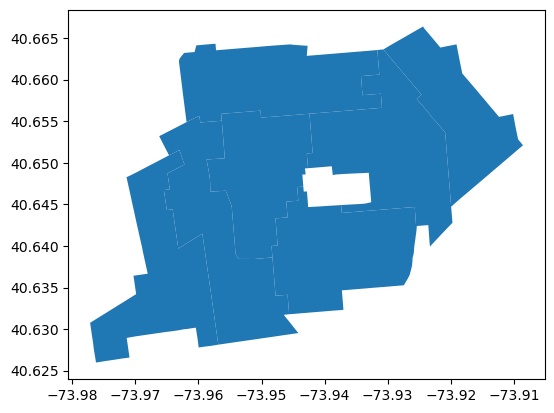

In [1232]:
#find center of map 
fb_neighborhoods_gdf.plot()
# use coordinates 40.650, -73.95 for location


In [1285]:
m = folium.Map(location=[40.65, -73.95], zoom_start=13)
m

In [1279]:
# add neighborhoods to map

In [1288]:
# style
g = folium.GeoJson(
    fb_neighborhoods_gdf,
    style_function=lambda x: {
        "stroke":False,
        "fillColor": '#d6a5c9',
        "color": "#bab0ac",
        "fillOpacity": 0.1,
    },
    tooltip=None,
    highlight_function=None,
).add_to(m)


In [1289]:
#add roads

r = folium.GeoJson(
    family_roads_gdf2,
    tooltip=folium.GeoJsonTooltip(
        fields=["FULLNAME"],
        aliases=["Street"],
        localize=True,
        sticky=False,
        labels=True,
        style="""
            background-color: #F0EFEF;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
            """,
        max_width=800,
    ),
    style_function=lambda feature: {
        "color": "#88d27a",
        "weight": 5,
        
    },
).add_to(m)

#popup = folium.GeoJsonPopup(
 #   fields=["name", "change"],
  #  aliases=["State", "% Change"],
   # localize=True,
    #labels=True,
    #style="background-color: yellow;",
#)



In [1290]:
m

# Create new gdf that contains tooltip and popup data #

## create names column in family_roads_gdf2 ##
* add names from family_df
* remsen doesn't have any names
## create chart columns in family_roads_gdf2 ##
* add one column for html charts (c_html)
* add one column for json charts (c_json)
* test to see which one loads best


In [1324]:
# create names column

In [1342]:
family_roads_gdf2['Names'] = ''

In [1344]:
family_roads_gdf2

,LINEARID,FULLNAME,RTTYP,MTFCC,geometry,Names
857,110422538084,Remsen Ave,M,S1400,"LINESTRING (-73.93158 40.66323, -73.93108 40.6...",
1354,110422541060,Clarkson Ave,M,S1400,"LINESTRING (-73.9597 40.65484, -73.9563 40.655...",
1369,110422541061,Clarkson Ave,M,S1400,"LINESTRING (-73.92541 40.65768, -73.92464 40.6...",
1375,110422535821,Ditmas Ave,M,S1400,"LINESTRING (-73.92262 40.64273, -73.92174 40.6...",
1731,110422535822,Ditmas Ave,M,S1400,"LINESTRING (-73.97911 40.63544, -73.97802 40.6...",
1851,110422543072,Vanderveer Pl,M,S1400,"LINESTRING (-73.95707 40.64196, -73.95541 40.6...",
2059,110422541452,Lefferts Ave,M,S1400,"LINESTRING (-73.96143 40.66169, -73.96077 40.6...",
2183,110422535820,Ditmas Ave,M,S1400,"LINESTRING (-73.96763 40.63524, -73.96712 40.6...",
2300,110422542259,Cortelyou Rd,M,S1400,"LINESTRING (-73.97955 40.63782, -73.97912 40.6...",
2446,110422541517,Martense St,M,S1400,"LINESTRING (-73.95893 40.65121, -73.95801 40.6...",


In [1349]:
# replace what is in each loc with names taken from the list 
# skip the remsens

In [1350]:
# Clarkson Ave, 1354 and 1369
family_roads_gdf2.loc[1354, 'Names']

''

In [1351]:
family_df.index
family_df.loc['Clarkson','Enslaved Names']

['Henck', 'Saar', 'Ben', 'Jafta']

In [1354]:
family_roads_gdf2.loc[1354, 'Names'] = 'Henck, Saar, Ben, Jafta'

In [1356]:
family_roads_gdf2.loc[1369, 'Names'] = 'Henck, Saar, Ben, Jafta'

In [1359]:
# Ditmas Ave, 1375 and 1731
family_roads_gdf2.loc[1375, 'Names'] = 'Jacob, Harry'

In [1361]:
family_roads_gdf2.loc[1731, 'Names'] = 'Jacob, Harry'

In [1363]:
# Vanderveer Pl, 1851
family_roads_gdf2.loc[1851, 'Names']

''

In [1362]:
family_roads_gdf2

,LINEARID,FULLNAME,RTTYP,MTFCC,geometry,Names
857,110422538084,Remsen Ave,M,S1400,"LINESTRING (-73.93158 40.66323, -73.93108 40.6...",
1354,110422541060,Clarkson Ave,M,S1400,"LINESTRING (-73.9597 40.65484, -73.9563 40.655...","Henck, Saar, Ben, Jafta"
1369,110422541061,Clarkson Ave,M,S1400,"LINESTRING (-73.92541 40.65768, -73.92464 40.6...","Henck, Saar, Ben, Jafta"
1375,110422535821,Ditmas Ave,M,S1400,"LINESTRING (-73.92262 40.64273, -73.92174 40.6...","Jacob, Harry"
1731,110422535822,Ditmas Ave,M,S1400,"LINESTRING (-73.97911 40.63544, -73.97802 40.6...","Jacob, Harry"
1851,110422543072,Vanderveer Pl,M,S1400,"LINESTRING (-73.95707 40.64196, -73.95541 40.6...",
2059,110422541452,Lefferts Ave,M,S1400,"LINESTRING (-73.96143 40.66169, -73.96077 40.6...",
2183,110422535820,Ditmas Ave,M,S1400,"LINESTRING (-73.96763 40.63524, -73.96712 40.6...",
2300,110422542259,Cortelyou Rd,M,S1400,"LINESTRING (-73.97955 40.63782, -73.97912 40.6...",
2446,110422541517,Martense St,M,S1400,"LINESTRING (-73.95893 40.65121, -73.95801 40.6...",


In [1367]:
#going to export this df to csv, remove names from list in open refine. then import
family_df.to_csv('family_df_listed.csv')
#converted all lists to regular strings. re-importing
familydf = pd.read_csv('/Users/Maya/Documents/Education/Pratt/Programming for Cultural Heritage/Final Project/family-df.csv')

In [1369]:
familydf

,Column,Enslaved Names
0,Lefferts,"Jack, Isabel, Samuel, Isabella, Cato, Mercy, I..."
1,Lott,"Francis, Sarah, Bet, Tom, Sarah, Bett, Cuff, W..."
2,Martense,"Lans, Pagg, Margaret, Mary, Isabella, Sare, Be..."
3,Clarkson,"Henck, Saar, Ben, Jafta"
4,Cortelyou,"Sick, Dina, Tom"
5,Ditmas,"Jacob, Harry"
6,Vanderveer,"Deyawn, Francis, Joe, Sawr"


In [1374]:
familydf = familydf.rename(columns={'Column':'Family'})

In [1378]:
familydf_names = familydf.set_index('Family')

In [1379]:
familydf_names

,Enslaved Names
Family,
Lefferts,"Jack, Isabel, Samuel, Isabella, Cato, Mercy, I..."
Lott,"Francis, Sarah, Bet, Tom, Sarah, Bett, Cuff, W..."
Martense,"Lans, Pagg, Margaret, Mary, Isabella, Sare, Be..."
Clarkson,"Henck, Saar, Ben, Jafta"
Cortelyou,"Sick, Dina, Tom"
Ditmas,"Jacob, Harry"
Vanderveer,"Deyawn, Francis, Joe, Sawr"


In [1380]:
# going to export family_roads_gdf2 to csv and add in the rest of the names to save time

family_roads_gdf2.to_csv('family_roads.csv')

In [1382]:
#in openrefine
# will add names and then delete some columns and re-import as df

In [1387]:
pd.read_csv('/Users/Maya/Documents/Education/Pratt/Programming for Cultural Heritage/Final Project/family-roadsgdf.csv')

,Column,LINEARID,FULLNAME,geometry,Names,c_html,c_json
0,857,110422538084,Remsen Ave,"LINESTRING (-73.931579 40.66323, -73.931077 40...",NaN,NaN,NaN
1,1354,110422541060,Clarkson Ave,"LINESTRING (-73.959696 40.654839, -73.9563 40....","Henck, Saar, Ben, Jafta",NaN,NaN
2,1369,110422541061,Clarkson Ave,"LINESTRING (-73.925407 40.65768, -73.924643 40...","Henck, Saar, Ben, Jafta",NaN,NaN
3,1375,110422535821,Ditmas Ave,"LINESTRING (-73.922615 40.642733, -73.921741 4...","Jacob, Harry",NaN,NaN
4,1731,110422535822,Ditmas Ave,"LINESTRING (-73.979112 40.63544, -73.978022 40...","Jacob, Harry",NaN,NaN
5,1851,110422543072,Vanderveer Pl,"LINESTRING (-73.95707 40.641961, -73.95541 40....","Deyawn, Francis, Joe, Sawr",NaN,NaN
6,2059,110422541452,Lefferts Ave,"LINESTRING (-73.961429 40.661691, -73.96077 40...","Jack, Isabel, Samuel, Isabella, Cato, Mercy, I...",NaN,NaN
7,2183,110422535820,Ditmas Ave,"LINESTRING (-73.967627 40.635238, -73.967123 4...","Jacob, Harry",NaN,NaN
8,2300,110422542259,Cortelyou Rd,"LINESTRING (-73.979554 40.637819, -73.979118 4...","Sick, Dina, Tom",NaN,NaN
9,2446,110422541517,Martense St,"LINESTRING (-73.958926 40.651212, -73.958014 4...","Lans, Pagg, Margaret, Mary, Isabella, Sare, Be...",NaN,NaN


In [1388]:
pd.read_csv('/Users/Maya/Documents/Education/Pratt/Programming for Cultural Heritage/family-roadsgdf.csv')

,Column,LINEARID,FULLNAME,geometry,Names,c_html,c_json
0,857,110422538084,Remsen Ave,"LINESTRING (-73.931579 40.66323, -73.931077 40...",NaN,remsen_line.html,remsen_line.json
1,1354,110422541060,Clarkson Ave,"LINESTRING (-73.959696 40.654839, -73.9563 40....","Henck, Saar, Ben, Jafta",NaN,NaN
2,1369,110422541061,Clarkson Ave,"LINESTRING (-73.925407 40.65768, -73.924643 40...","Henck, Saar, Ben, Jafta",NaN,NaN
3,1375,110422535821,Ditmas Ave,"LINESTRING (-73.922615 40.642733, -73.921741 4...","Jacob, Harry",NaN,NaN
4,1731,110422535822,Ditmas Ave,"LINESTRING (-73.979112 40.63544, -73.978022 40...","Jacob, Harry",NaN,NaN
5,1851,110422543072,Vanderveer Pl,"LINESTRING (-73.95707 40.641961, -73.95541 40....","Deyawn, Francis, Joe, Sawr",NaN,NaN
6,2059,110422541452,Lefferts Ave,"LINESTRING (-73.961429 40.661691, -73.96077 40...","Jack, Isabel, Samuel, Isabella, Cato, Mercy, I...",NaN,NaN
7,2183,110422535820,Ditmas Ave,"LINESTRING (-73.967627 40.635238, -73.967123 4...","Jacob, Harry",NaN,NaN
8,2300,110422542259,Cortelyou Rd,"LINESTRING (-73.979554 40.637819, -73.979118 4...","Sick, Dina, Tom",NaN,NaN
9,2446,110422541517,Martense St,"LINESTRING (-73.958926 40.651212, -73.958014 4...","Lans, Pagg, Margaret, Mary, Isabella, Sare, Be...",NaN,NaN


In [1394]:
pd.read_csv('/Users/Maya/Documents/Education/Pratt/Programming for Cultural Heritage/family-roadsgdf.csv')

,Column,LINEARID,FULLNAME,geometry,Names,c_html,c_json
0,857,110422538084,Remsen Ave,"LINESTRING (-73.931579 40.66323, -73.931077 40...",NaN,remsen_line.html,remsen_line.json
1,1354,110422541060,Clarkson Ave,"LINESTRING (-73.959696 40.654839, -73.9563 40....","Henck, Saar, Ben, Jafta",NaN,NaN
2,1369,110422541061,Clarkson Ave,"LINESTRING (-73.925407 40.65768, -73.924643 40...","Henck, Saar, Ben, Jafta",NaN,NaN
3,1375,110422535821,Ditmas Ave,"LINESTRING (-73.922615 40.642733, -73.921741 4...","Jacob, Harry",NaN,NaN
4,1731,110422535822,Ditmas Ave,"LINESTRING (-73.979112 40.63544, -73.978022 40...","Jacob, Harry",NaN,NaN
5,1851,110422543072,Vanderveer Pl,"LINESTRING (-73.95707 40.641961, -73.95541 40....","Deyawn, Francis, Joe, Sawr",NaN,NaN
6,2059,110422541452,Lefferts Ave,"LINESTRING (-73.961429 40.661691, -73.96077 40...","Jack, Isabel, Samuel, Isabella, Cato, Mercy, I...",NaN,NaN
7,2183,110422535820,Ditmas Ave,"LINESTRING (-73.967627 40.635238, -73.967123 4...","Jacob, Harry",NaN,NaN
8,2300,110422542259,Cortelyou Rd,"LINESTRING (-73.979554 40.637819, -73.979118 4...","Sick, Dina, Tom",NaN,NaN
9,2446,110422541517,Martense St,"LINESTRING (-73.958926 40.651212, -73.958014 4...","Lans, Pagg, Margaret, Mary, Isabella, Sare, Be...",NaN,NaN


In [1401]:
#test_gdf_popup = 
pd.read_csv('/Users/Maya/Documents/Education/Pratt/Programming for Cultural Heritage/family-roadsgdf.csv')

,Family,LINEARID,FULLNAME,geometry,Names
0,Remsen,110422538084,Remsen Ave,"LINESTRING (-73.931579 40.66323, -73.931077 40...",No names available
1,Clarkson,110422541060,Clarkson Ave,"LINESTRING (-73.959696 40.654839, -73.9563 40....","Henck, Saar, Ben, Jafta"
2,Clarkson,110422541061,Clarkson Ave,"LINESTRING (-73.925407 40.65768, -73.924643 40...","Henck, Saar, Ben, Jafta"
3,Ditmas,110422535821,Ditmas Ave,"LINESTRING (-73.922615 40.642733, -73.921741 4...","Jacob, Harry"
4,Ditmas,110422535822,Ditmas Ave,"LINESTRING (-73.979112 40.63544, -73.978022 40...","Jacob, Harry"
5,Vanderveer,110422543072,Vanderveer Pl,"LINESTRING (-73.95707 40.641961, -73.95541 40....","Deyawn, Francis, Joe, Sawr"
6,Lefferts,110422541452,Lefferts Ave,"LINESTRING (-73.961429 40.661691, -73.96077 40...","Jack, Isabel, Samuel, Isabella, Cato, Mercy, I..."
7,Ditmas,110422535820,Ditmas Ave,"LINESTRING (-73.967627 40.635238, -73.967123 4...","Jacob, Harry"
8,Cortelyou,110422542259,Cortelyou Rd,"LINESTRING (-73.979554 40.637819, -73.979118 4...","Sick, Dina, Tom"
9,Martense,110422541517,Martense St,"LINESTRING (-73.958926 40.651212, -73.958014 4...","Lans, Pagg, Margaret, Mary, Isabella, Sare, Be..."


In [1402]:
names_and_streetsgdf = pd.read_csv('/Users/Maya/Documents/Education/Pratt/Programming for Cultural Heritage/family-roadsgdf.csv')

In [1403]:
# going to cleanup the df since the popups didn't work and it won't load with NaNs



In [1389]:
# testing out whether the map still loads with this new information

In [1635]:
m2 = folium.Map(location=[40.65, -73.95], zoom_start=13)
m2

In [1636]:
# adding neighborhoods

g2 = folium.GeoJson(
    fb_neighborhoods_gdf,
    style_function=lambda x: {
        "stroke":False,
        "fillColor": '#d6a5c9',
        "color": "#bab0ac",
        "fillOpacity": 0.1,
    },
    tooltip=None,
    highlight_function=None,
).add_to(m2)

In [1413]:
m2

In [1637]:
#add roads

r2 = folium.GeoJson(
    family_roads_gdf3,
    tooltip=folium.GeoJsonTooltip(
        fields=['Family',"FULLNAME_x", "Names"],
        aliases=["Family","Street", "Enslaved People"],
        localize=True,
        sticky=False,
        labels=True,
        style="""
            background-color: #F0EFEF;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
            """,
        max_width=150,
        max_height=300,
    ),
    style_function=lambda feature: {
        "color": "#9d755d",
        "weight": 5,    
    },

    
).add_to(m2)




In [1415]:
family_roads_gdf2

,LINEARID,FULLNAME,RTTYP,MTFCC,geometry,Names
857,110422538084,Remsen Ave,M,S1400,"LINESTRING (-73.93158 40.66323, -73.93108 40.6...",
1354,110422541060,Clarkson Ave,M,S1400,"LINESTRING (-73.9597 40.65484, -73.9563 40.655...","Henck, Saar, Ben, Jafta"
1369,110422541061,Clarkson Ave,M,S1400,"LINESTRING (-73.92541 40.65768, -73.92464 40.6...","Henck, Saar, Ben, Jafta"
1375,110422535821,Ditmas Ave,M,S1400,"LINESTRING (-73.92262 40.64273, -73.92174 40.6...","Jacob, Harry"
1731,110422535822,Ditmas Ave,M,S1400,"LINESTRING (-73.97911 40.63544, -73.97802 40.6...","Jacob, Harry"
1851,110422543072,Vanderveer Pl,M,S1400,"LINESTRING (-73.95707 40.64196, -73.95541 40.6...",
2059,110422541452,Lefferts Ave,M,S1400,"LINESTRING (-73.96143 40.66169, -73.96077 40.6...",
2183,110422535820,Ditmas Ave,M,S1400,"LINESTRING (-73.96763 40.63524, -73.96712 40.6...",
2300,110422542259,Cortelyou Rd,M,S1400,"LINESTRING (-73.97955 40.63782, -73.97912 40.6...",
2446,110422541517,Martense St,M,S1400,"LINESTRING (-73.95893 40.65121, -73.95801 40.6...",


In [1416]:
family_roads_gdf2['geometry']

857     LINESTRING (-73.93158 40.66323, -73.93108 40.6...
1354    LINESTRING (-73.9597 40.65484, -73.9563 40.655...
1369    LINESTRING (-73.92541 40.65768, -73.92464 40.6...
1375    LINESTRING (-73.92262 40.64273, -73.92174 40.6...
1731    LINESTRING (-73.97911 40.63544, -73.97802 40.6...
1851    LINESTRING (-73.95707 40.64196, -73.95541 40.6...
2059    LINESTRING (-73.96143 40.66169, -73.96077 40.6...
2183    LINESTRING (-73.96763 40.63524, -73.96712 40.6...
2300    LINESTRING (-73.97955 40.63782, -73.97912 40.6...
2446    LINESTRING (-73.95893 40.65121, -73.95801 40.6...
2815    LINESTRING (-73.96879 40.63926, -73.96792 40.6...
3248    LINESTRING (-73.95805 40.65173, -73.95801 40.6...
1106    LINESTRING (-73.95421 40.64794, -73.95412 40.6...
1850    LINESTRING (-73.95417 40.64959, -73.95409 40.6...
Name: geometry, dtype: geometry

In [1420]:
names_and_streetsgdf['geometry'].astype

<bound method NDFrame.astype of 0     LINESTRING (-73.931579 40.66323, -73.931077 40...
1     LINESTRING (-73.959696 40.654839, -73.9563 40....
2     LINESTRING (-73.925407 40.65768, -73.924643 40...
3     LINESTRING (-73.922615 40.642733, -73.921741 4...
4     LINESTRING (-73.979112 40.63544, -73.978022 40...
5     LINESTRING (-73.95707 40.641961, -73.95541 40....
6     LINESTRING (-73.961429 40.661691, -73.96077 40...
7     LINESTRING (-73.967627 40.635238, -73.967123 4...
8     LINESTRING (-73.979554 40.637819, -73.979118 4...
9     LINESTRING (-73.958926 40.651212, -73.958014 4...
10    LINESTRING (-73.968791 40.639256, -73.967917 4...
11    LINESTRING (-73.958054 40.651733, -73.958014 4...
12    LINESTRING (-73.954212 40.647936, -73.954125 4...
13    LINESTRING (-73.954171 40.649592, -73.954086 4...
Name: geometry, dtype: object>

In [1422]:
names_and_streetsgdf

,Family,LINEARID,FULLNAME,geometry,Names
0,Remsen,110422538084,Remsen Ave,"LINESTRING (-73.931579 40.66323, -73.931077 40...",No names available
1,Clarkson,110422541060,Clarkson Ave,"LINESTRING (-73.959696 40.654839, -73.9563 40....","Henck, Saar, Ben, Jafta"
2,Clarkson,110422541061,Clarkson Ave,"LINESTRING (-73.925407 40.65768, -73.924643 40...","Henck, Saar, Ben, Jafta"
3,Ditmas,110422535821,Ditmas Ave,"LINESTRING (-73.922615 40.642733, -73.921741 4...","Jacob, Harry"
4,Ditmas,110422535822,Ditmas Ave,"LINESTRING (-73.979112 40.63544, -73.978022 40...","Jacob, Harry"
5,Vanderveer,110422543072,Vanderveer Pl,"LINESTRING (-73.95707 40.641961, -73.95541 40....","Deyawn, Francis, Joe, Sawr"
6,Lefferts,110422541452,Lefferts Ave,"LINESTRING (-73.961429 40.661691, -73.96077 40...","Jack, Isabel, Samuel, Isabella, Cato, Mercy, I..."
7,Ditmas,110422535820,Ditmas Ave,"LINESTRING (-73.967627 40.635238, -73.967123 4...","Jacob, Harry"
8,Cortelyou,110422542259,Cortelyou Rd,"LINESTRING (-73.979554 40.637819, -73.979118 4...","Sick, Dina, Tom"
9,Martense,110422541517,Martense St,"LINESTRING (-73.958926 40.651212, -73.958014 4...","Lans, Pagg, Margaret, Mary, Isabella, Sare, Be..."


In [1423]:
# going to drop the object type geometry column from names_and_streetsgdf and then merge it to 
#family_roads_gdf2

In [1435]:
family_roads_gdf2.drop(columns='Names')
family_roads_gdf2 = family_roads_gdf2.drop(columns='Names')

In [1425]:
names_streets_tooltipgdf = family_roads_gdf2.drop(columns='Names')

In [1427]:
names_streets_tooltipgdf
names_streets_tooltipgdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 14 entries, 857 to 1850
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LINEARID  14 non-null     object  
 1   FULLNAME  14 non-null     object  
 2   RTTYP     14 non-null     object  
 3   MTFCC     14 non-null     object  
 4   geometry  14 non-null     geometry
dtypes: geometry(1), object(4)
memory usage: 1.2+ KB


In [1428]:
# dropping object/fake geometry column from names_and_streetsgdf

In [1432]:
names_and_streetsgdf.drop(columns='geometry')
names_and_streetsmerge = names_and_streetsgdf.drop(columns='geometry')
names_and_streetsmerge

,Family,LINEARID,FULLNAME,Names
0,Remsen,110422538084,Remsen Ave,No names available
1,Clarkson,110422541060,Clarkson Ave,"Henck, Saar, Ben, Jafta"
2,Clarkson,110422541061,Clarkson Ave,"Henck, Saar, Ben, Jafta"
3,Ditmas,110422535821,Ditmas Ave,"Jacob, Harry"
4,Ditmas,110422535822,Ditmas Ave,"Jacob, Harry"
5,Vanderveer,110422543072,Vanderveer Pl,"Deyawn, Francis, Joe, Sawr"
6,Lefferts,110422541452,Lefferts Ave,"Jack, Isabel, Samuel, Isabella, Cato, Mercy, I..."
7,Ditmas,110422535820,Ditmas Ave,"Jacob, Harry"
8,Cortelyou,110422542259,Cortelyou Rd,"Sick, Dina, Tom"
9,Martense,110422541517,Martense St,"Lans, Pagg, Margaret, Mary, Isabella, Sare, Be..."


In [1433]:
# using shared column LINEARID for merge

In [1438]:
family_roads_gdf2.merge(names_and_streetsmerge, how='left', on='LINEARID')

ValueError: You are trying to merge on object and int64 columns for key 'LINEARID'. If you wish to proceed you should use pd.concat

In [1439]:
# error. must change data types in names_and_streetsmerge to match

In [1453]:
family_roads_gdf2.info()
family_roads_gdf2['LINEARID'].loc[857]

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 14 entries, 857 to 1850
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LINEARID  14 non-null     object  
 1   FULLNAME  14 non-null     object  
 2   RTTYP     14 non-null     object  
 3   MTFCC     14 non-null     object  
 4   geometry  14 non-null     geometry
dtypes: geometry(1), object(4)
memory usage: 1.2+ KB


'110422538084'

In [1444]:
names_and_streetsmerge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Family    14 non-null     object
 1   LINEARID  14 non-null     int64 
 2   FULLNAME  14 non-null     object
 3   Names     14 non-null     object
dtypes: int64(1), object(3)
memory usage: 580.0+ bytes


In [1459]:
names_and_streetsmerge['LINEARID'].astype('str')

0      110422538084
1      110422541060
2      110422541061
3      110422535821
4      110422535822
5      110422543072
6      110422541452
7      110422535820
8      110422542259
9      110422541517
10    1104991851762
11     110422541514
12     110422532813
13     110422532812
Name: LINEARID, dtype: object

In [1461]:
names_and_streetsmerge['LINEARID'] = names_and_streetsmerge['LINEARID'].astype('str')

In [1463]:
names_and_streetsmerge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Family    14 non-null     object
 1   LINEARID  14 non-null     object
 2   FULLNAME  14 non-null     object
 3   Names     14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


In [1464]:
# okay trying the merge again

In [1465]:
family_roads_gdf2.merge(names_and_streetsmerge, how='left', on='LINEARID')

,LINEARID,FULLNAME_x,RTTYP,MTFCC,geometry,Family,FULLNAME_y,Names
0,110422538084,Remsen Ave,M,S1400,"LINESTRING (-73.93158 40.66323, -73.93108 40.6...",Remsen,Remsen Ave,No names available
1,110422541060,Clarkson Ave,M,S1400,"LINESTRING (-73.9597 40.65484, -73.9563 40.655...",Clarkson,Clarkson Ave,"Henck, Saar, Ben, Jafta"
2,110422541061,Clarkson Ave,M,S1400,"LINESTRING (-73.92541 40.65768, -73.92464 40.6...",Clarkson,Clarkson Ave,"Henck, Saar, Ben, Jafta"
3,110422535821,Ditmas Ave,M,S1400,"LINESTRING (-73.92262 40.64273, -73.92174 40.6...",Ditmas,Ditmas Ave,"Jacob, Harry"
4,110422535822,Ditmas Ave,M,S1400,"LINESTRING (-73.97911 40.63544, -73.97802 40.6...",Ditmas,Ditmas Ave,"Jacob, Harry"
5,110422543072,Vanderveer Pl,M,S1400,"LINESTRING (-73.95707 40.64196, -73.95541 40.6...",Vanderveer,Vanderveer Pl,"Deyawn, Francis, Joe, Sawr"
6,110422541452,Lefferts Ave,M,S1400,"LINESTRING (-73.96143 40.66169, -73.96077 40.6...",Lefferts,Lefferts Ave,"Jack, Isabel, Samuel, Isabella, Cato, Mercy, I..."
7,110422535820,Ditmas Ave,M,S1400,"LINESTRING (-73.96763 40.63524, -73.96712 40.6...",Ditmas,Ditmas Ave,"Jacob, Harry"
8,110422542259,Cortelyou Rd,M,S1400,"LINESTRING (-73.97955 40.63782, -73.97912 40.6...",Cortelyou,Cortelyou Rd,"Sick, Dina, Tom"
9,110422541517,Martense St,M,S1400,"LINESTRING (-73.95893 40.65121, -73.95801 40.6...",Martense,Martense St,"Lans, Pagg, Margaret, Mary, Isabella, Sare, Be..."


In [1469]:
family_roads_gdf3 = family_roads_gdf2.merge(names_and_streetsmerge, how='left', on='LINEARID').copy()

In [1474]:
family_roads_gdf3 = family_roads_gdf3.drop(columns=['RTTYP', 'MTFCC', 'FULLNAME_y'])

KeyError: "['RTTYP', 'MTFCC', 'FULLNAME_y'] not found in axis"

In [1476]:
family_roads_gdf3.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LINEARID    14 non-null     object  
 1   FULLNAME_x  14 non-null     object  
 2   geometry    14 non-null     geometry
 3   Family      14 non-null     object  
 4   Names       14 non-null     object  
dtypes: geometry(1), object(4)
memory usage: 692.0+ bytes


In [1477]:
#retrying my maps

In [1489]:
m2

## Adding Popups and Markers Using geocoding ##
* create gdf with points
* use tutorial from folium to add point features
* create remaining vega charts for families
* add to map
* export map

In [1490]:
# create popup gdf
popup_df = pd.DataFrame(
    {
        "Last Name": ["Lott", "Martense", "Lefferts", "Vanderveer", "Remsen", "Clarkson", "Cortelyou", "Ditmas"],
        "Streets": ["Lott St", "Martense St", "Lefferts Ave", "Vanderveer Pl", "Remsen Ave", "Clarkson Ave", "Cortelyou Rd", "Ditmas Ave"],
        "Latitude": [40.645753,  40.6515944,  40.6622602, 40.6420544,  40.6571323, 40.6561492, 40.6443458, 40.6404325],
        "Longitude": [-73.9540491, -73.9516199, -73.9523160, -73.9555352, -73.9247969, -73.9381911, -73.9507203, -73.9562272],
    }
)

In [1491]:
popup_df

,Last Name,Streets,Latitude,Longitude
0,Lott,Lott St,40.645753,-73.954049
1,Martense,Martense St,40.651594,-73.951620
2,Lefferts,Lefferts Ave,40.662260,-73.952316
3,Vanderveer,Vanderveer Pl,40.642054,-73.955535
4,Remsen,Remsen Ave,40.657132,-73.924797
5,Clarkson,Clarkson Ave,40.656149,-73.938191
6,Cortelyou,Cortelyou Rd,40.644346,-73.950720
7,Ditmas,Ditmas Ave,40.640433,-73.956227


In [1494]:
# turns the previous dataframe into a geodataframe

popup_gdf = gpd.GeoDataFrame(
    popup_df, geometry=gpd.points_from_xy(popup_df.Longitude, popup_df.Latitude), crs="EPSG:4326"
)

In [1495]:
popup_gdf

,Last Name,Streets,Latitude,Longitude,geometry
0,Lott,Lott St,40.645753,-73.954049,POINT (-73.95405 40.64575)
1,Martense,Martense St,40.651594,-73.951620,POINT (-73.95162 40.65159)
2,Lefferts,Lefferts Ave,40.662260,-73.952316,POINT (-73.95232 40.66226)
3,Vanderveer,Vanderveer Pl,40.642054,-73.955535,POINT (-73.95554 40.64205)
4,Remsen,Remsen Ave,40.657132,-73.924797,POINT (-73.9248 40.65713)
5,Clarkson,Clarkson Ave,40.656149,-73.938191,POINT (-73.93819 40.65615)
6,Cortelyou,Cortelyou Rd,40.644346,-73.950720,POINT (-73.95072 40.64435)
7,Ditmas,Ditmas Ave,40.640433,-73.956227,POINT (-73.95623 40.64043)


In [1496]:
# Create a geometry list from the GeoDataFrame

In [1497]:
popup_list = [[point.xy[1][0], point.xy[0][0]] for point in popup_gdf.geometry]

In [1498]:
popup_list

[[40.645753, -73.9540491],
 [40.6515944, -73.9516199],
 [40.6622602, -73.952316],
 [40.6420544, -73.9555352],
 [40.6571323, -73.9247969],
 [40.6561492, -73.9381911],
 [40.6443458, -73.9507203],
 [40.6404325, -73.9562272]]

In [1501]:
# realized that I cannot iterate with the vega data :( will make markers one by one


In [1503]:
import json

In [1623]:
remsen_linechart
vega_remsen = folium.VegaLite(
    remsen_linechart,
    width="100%",
    height="100%",
)

In [1638]:
remsen_marker = folium.Marker(
    location=[40.657132, -73.924797],
    icon=folium.Icon(color="purple")
)
remsen_popup = folium.Popup()


vega_remsen.add_to(remsen_popup)
remsen_popup.add_to(remsen_marker)

remsen_marker.add_to(m2)

## create vega-lite charts for families with existing matplotlib charts and add to pop up markers ##
* copy code used for remsen
* use for families that had matplotlib charts
* use existing vega tables for other families
* insert into map

In [1539]:
lefferts_sum
lefferts_sum.reset_index()
reset_lefferts = lefferts_sum.reset_index().copy()
reset_lefferts

,RecYear,Slaves
0,1755-01-01,6.0
1,1790-01-01,26.0
2,1800-01-01,8.0
3,1810-01-01,5.0
4,1820-01-01,8.0


In [1542]:
# Create a line plot
lefferts_linechart = alt.Chart(reset_lefferts).mark_line(point=True).encode(
    x=alt.X("RecYear:T", timeUnit='year', title='Year', scale=alt.Scale(domain=(1745,1825))),
    y= alt.Y('Slaves', title='People', scale=alt.Scale(domain=(0,28))),
    tooltip=[alt.X("RecYear:T", timeUnit='year', title='Year'), alt.Y('Slaves', title='Enslaved People')],
    color=alt.value("#72b7b2")
).properties(
    title='People Enslaved by the Lefferts Family'
)

lefferts_linechart.save('lefferts_line.html')
lefferts_linechart.save('lefferts_line.json')

In [1543]:
# create vega object

lefferts_linechart
vega_lefferts = folium.VegaLite(
    lefferts_linechart,
    width="100%",
    height="100%",
)

In [1639]:
lefferts_marker = folium.Marker(
    location=[40.662260, -73.952316],
    icon=folium.Icon(color="lightblue")
)
lefferts_popup = folium.Popup()


vega_lefferts.add_to(lefferts_popup)
lefferts_popup.add_to(lefferts_marker)

lefferts_marker.add_to(m2)

In [1557]:
lott_sum
lott_sum.reset_index()
reset_lott = lott_sum.reset_index().copy()
reset_lott

,RecYear,Slaves
0,1698-01-01,5.0
1,1738-01-01,10.0
2,1755-01-01,13.0
3,1790-01-01,53.0
4,1800-01-01,44.0
5,1810-01-01,36.0
6,1820-01-01,29.0


In [1559]:
# Create a line plot
lott_linechart = alt.Chart(reset_lott).mark_line(point=True).encode(
    x=alt.X("RecYear:T", timeUnit='year', title='Year', scale=alt.Scale(domain=(1690,1825))),
    y= alt.Y('Slaves', title='People', scale=alt.Scale(domain=(0,55))),
    tooltip=[alt.X("RecYear:T", timeUnit='year', title='Year'), alt.Y('Slaves', title='Enslaved People')],
    color=alt.value("#54a24b")
).properties(
    title='People Enslaved by the Lott Family'
)

lott_linechart
lott_linechart.save('lott_line.html')
lott_linechart.save('lott_line.json')

In [1560]:
# create vega object

lott_linechart
vega_lott = folium.VegaLite(
    lott_linechart,
    width="100%",
    height="100%",
)

In [1640]:
lott_marker = folium.Marker(
    location=[40.645753, -73.954049],
    icon=folium.Icon(color="green")
)
lott_popup = folium.Popup()


vega_lott.add_to(lott_popup)
lott_popup.add_to(lott_marker)

lott_marker.add_to(m2)

In [1564]:
martense_sum
martense_sum.reset_index()
reset_martense = martense_sum.reset_index().copy()
reset_martense

,RecYear,Slaves
0,1678-01-01,4.0
1,1738-01-01,8.0
2,1755-01-01,9.0
3,1800-01-01,33.0
4,1810-01-01,29.0


In [1566]:
# Create a line plot
martense_linechart = alt.Chart(reset_martense).mark_line(point=True).encode(
    x=alt.X("RecYear:T", timeUnit='year', title='Year', scale=alt.Scale(domain=(1670,1815))),
    y= alt.Y('Slaves', title='People', scale=alt.Scale(domain=(0,55))),
    tooltip=[alt.X("RecYear:T", timeUnit='year', title='Year'), alt.Y('Slaves', title='Enslaved People')],
    color=alt.value("#eeca3b")
).properties(
    title='People Enslaved by the Martense Family'
)

martense_linechart
martense_linechart.save('martense_line.html')
martense_linechart.save('martense_line.json')

In [1568]:
# create vega object

martense_linechart
vega_martense = folium.VegaLite(
    martense_linechart,
    width="100%",
    height="100%",
)

In [1641]:
martense_marker = folium.Marker(
    location=[40.651594, -73.951620],
    icon=folium.Icon(color="beige")
)
martense_popup = folium.Popup()


vega_martense.add_to(martense_popup)
martense_popup.add_to(martense_marker)

martense_marker.add_to(m2)

In [1572]:
vanderveer_sum
vanderveer_sum.reset_index()
reset_vanderveer = vanderveer_sum.reset_index().copy()
reset_vanderveer

,RecYear,Slaves
0,1698-01-01,1.0
1,1800-01-01,4.0
2,1810-01-01,5.0
3,1820-01-01,11.0


In [1582]:
# Create a line plot
vanderveer_linechart = alt.Chart(reset_vanderveer).mark_line(point=True).encode(
    x=alt.X("RecYear:T", timeUnit='year', title='Year', scale=alt.Scale(domain=(1690,1825))),
    y= alt.Y('Slaves', title='People', scale=alt.Scale(domain=(0,13))),
    tooltip=[alt.X("RecYear:T", timeUnit='year', title='Year'), alt.Y('Slaves', title='Enslaved People')],
    color=alt.value("#ff9da6")
).properties(
    title='People Enslaved by the Vanderveer Family'
)

vanderveer_linechart
vanderveer_linechart.save('vanderveer_line.html')
vanderveer_linechart.save('vanderveer_line.json')

In [1586]:
# create vega object

vanderveer_linechart
vega_vanderveer = folium.VegaLite(
    vanderveer_linechart,
    width="100%",
    height="100%",
)

In [1642]:
vanderveer_marker = folium.Marker(
    location=[40.642054, -73.955535],
    icon=folium.Icon(color="pink")
)
vanderveer_popup = folium.Popup()


vega_vanderveer.add_to(vanderveer_popup)
vanderveer_popup.add_to(vanderveer_marker)

vanderveer_marker.add_to(m2)

In [1601]:
clarkson_style_table
clarkson_sum_table

,Year,Enslaved People
0,1755,4


In [1643]:
clarkson_marker = folium.Marker(
    location=[40.656149, -73.938191],
    icon=folium.Icon(color="blue"),
    
)

clarkson_html = clarkson_sum_table.to_html(
    classes="table table-striped table-hover table-condensed table-responsive"
)
clarkson_popup = folium.Popup(clarkson_html)


clarkson_popup.add_to(clarkson_marker)

clarkson_marker.add_to(m2)

In [1615]:
cortelyou_sum_table


,Year,Enslaved People
0,1800,7


In [1644]:
cortelyou_marker = folium.Marker(
    location=[40.644346, -73.950720],
    icon=folium.Icon(color="orange"),
    
)

cortelyou_html = cortelyou_sum_table.to_html(
    classes="table table-striped table-hover table-condensed table-responsive"
)
cortelyou_popup = folium.Popup(cortelyou_html)


cortelyou_popup.add_to(cortelyou_marker)

cortelyou_marker.add_to(m2)

In [1619]:
ditmas_sum_table

,Year,Enslaved People
0,1810,6


In [1645]:
ditmas_marker = folium.Marker(
    location=[40.640433, -73.956227],
    icon=folium.Icon(color="red"),
    
)

ditmas_html = ditmas_sum_table.to_html(
    classes="table table-striped table-hover table-condensed table-responsive"
)
ditmas_popup = folium.Popup(ditmas_html)


ditmas_popup.add_to(ditmas_marker)

ditmas_marker.add_to(m2)

In [1646]:
m2

In [1648]:
final_map = m2

In [1649]:
final_map

In [1650]:
final_map.save('finalmap.html')

In [1651]:
final_map.save('finalmap.json')